# Модель поведенческого скоринга клиентов банка «Ва-банк»

- Автор: Евдокимов Александр
- Дата: 26.09.26

---

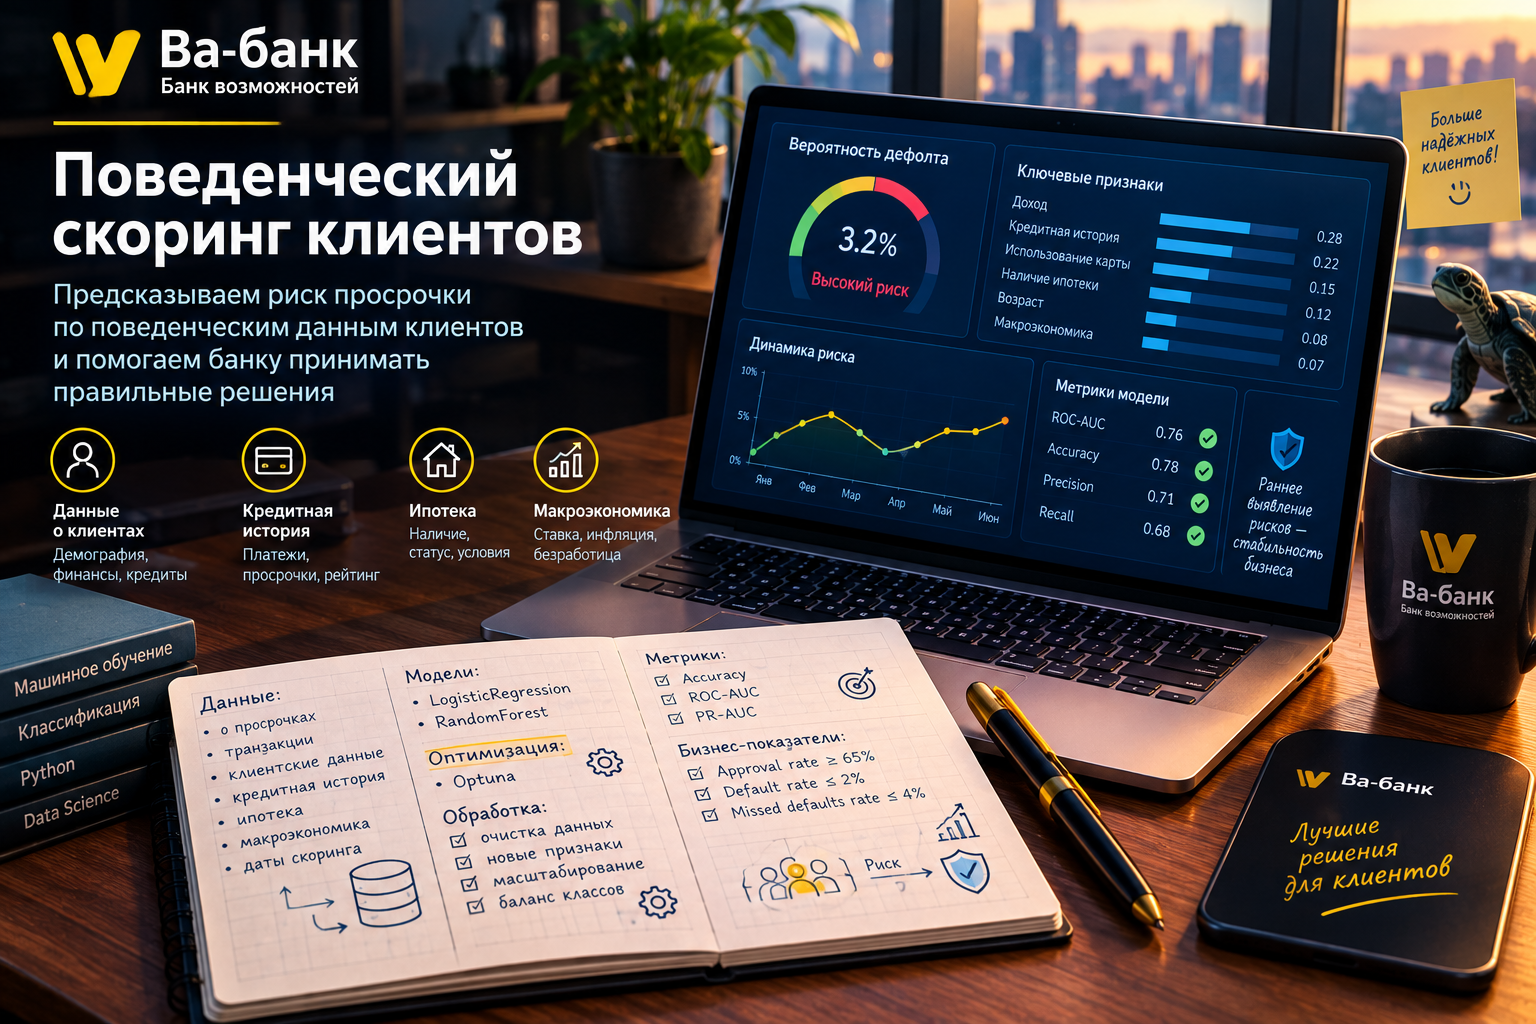

<a id='p1'></a>

---

## Подготовка рабочего пространства

<span style="font-size: 18px;">**Цель проекта**</span>

Разработать модель поведенческого скоринга, которая по данным о поведении действующего клиента банка в конкретном месяце прогнозирует возникновение просрочки длительностью 90 дней и более в течение следующих 12 месяцев.

Модель должна учитывать финансовое поведение клиента, его социально-демографические характеристики, кредитную историю, наличие ипотеки и макроэкономические показатели. Основная задача - заранее выявлять клиентов с повышенным риском дефолта и подобрать порог классификации, обеспечивающий приемлемый баланс между долей клиентов, которых модель считает надёжными, и количеством пропущенных дефолтов. Такой подход соответствует назначению поведенческого скоринга - выявлять ранние признаки роста кредитного риска у уже действующих клиентов банка.

<span style="font-size: 18px;">**Задачи проекта**</span>

В рамках указанной цели необходимо решить задачу бинарной классификации. Для её решения требуется выполнить следующие шаги:

1. Первичный анализ структуры и качества данных по каждой таблице.
2. Исследовательский анализ данных: проверка пропусков, дубликатов, выбросов и других особенностей.
3. Формирование датафрейма для обучения моделей и выделение целевой переменной.
4. Создание новых признаков.
5. Разделение данных на обучающую, калибровочную и тестовую выборки с учётом временной структуры.
6. Построение базовых моделей `LogisticRegression` и `RandomForestClassifier`.
7. Сравнение моделей на исходных несбалансированных данных и с применением методов балансировки классов.
8. Построение итоговой модели `RandomForestClassifier` и определение оптимальных гиперпараметров с помощью `Optuna`.
9. Калибровка вероятностных предсказаний лучшей модели.
10. Анализ важности признаков.
11. Формулирование итоговых выводов и рекомендаций по дальнейшему использованию модели.

Требования к решению включают использование `Random Forest` в качестве основной модели, трёхфолдовой кросс-валидации с `GroupTimeSeriesSplit()` и подбор не менее трёх гиперпараметров с помощью `Optuna`.

<a id='p2'></a>

---

## Постановка задачи машинного обучения

Задача проекта относится к обучению с учителем и является задачей бинарной классификации. Для каждого клиента в определённый месяц необходимо на основании доступной на этот момент информации оценить вероятность того, что в течение следующих 12 месяцев у клиента возникнет просрочка длительностью 90 дней или более.

Целевая переменная формируется следующим образом:
- `1` - если в течение следующих 12 месяцев возникает просрочка длительностью 90 дней и более;
- `0` - если такая просрочка в заданном горизонте не возникает.

В качестве базовых моделей будут рассмотрены:
- `LogisticRegression` - базовая линейная модель бинарной классификации;
- `RandomForestClassifier` - ансамблевая модель на основе решающих деревьев.

Для решения проблемы дисбаланса классов будут исследованы различные стратегии балансировки: `class_weight`, `RandomOverSampler`, `RandomUnderSampler`, `SMOTE`. Таким образом, будет проведено сравнение моделей, обученных как на исходных данных, так и с применением методов балансировки классов.

В качестве итогового алгоритма будет использован `RandomForestClassifier`. Для оценки его качества будет применяться кросс-валидация с тремя фолдами и временным разделением данных посредством `GroupTimeSeriesSplit()`, чтобы при обучении и проверке сохранялась временная структура наблюдений. Гиперпараметры модели планируется оптимизировать с помощью `Optuna`.

<span style="font-size: 18px;">**Метрики оценки**</span>

Качество модели будет оцениваться с помощью технических и бизнес-метрик. Основные бизнес-метрики:
- `Approval rate` = $\frac{FN + TN}{N}$ - доля клиентов, которых модель относит к надёжным (0).
- `Default rate` = $\frac{FN}{FN + TN}$ - доля клиентов с фактическим дефолтом среди клиентов, которых модель признала надёжными.
- `Missed defaults rate` = $\frac{FN}{FN + TP}$ = $1-Recall$ - доля дефолтов, которые модель не обнаружила.

Здесь $FN$ - клиенты, которые модель ошибочно посчитала надёжными; TN - клиенты, которые модель правильно посчитала надёжными; $N$ - общее число клиентов.

Дополнительно для сравнения моделей будут использоваться технические метрики: `Accuracy`, `ROC-AUC` или `PR-AUC`.

При выборе порога классификации необходимо одновременно обеспечить следующие условия:
- `Approval rate` $\ge$ 65%;
- `Default rate` $\le$ 2%;
- `Missed defaults rate` $\le$ 4%.

<span style="font-size: 18px;">**Описание данных**</span>

Для решения задачи предоставлено несколько таблиц, содержащих информацию о клиентах, их финансовом поведении, кредитах, рейтинге и макроэкономической ситуации. Все источники должны быть объединены в единую таблицу наблюдений перед построением моделей.

1. Данные о просрочках - `ds_15_loan_payment_credit.csv`. Содержат информацию о фактах просрочки:
    - `ID` - идентификатор клиента;
    - `дата_начала_периода` - дата начала периода просрочки;
    - `просрочка_дней` - длительность просрочки в днях.
2. Месячные транзакции - `ds_15_transactions.csv`. Содержат помесячные расходы клиента по категориям MCC:
    - `ID`;
    - `date`;
    - `MCC_5300`;
    - `MCC_5814`;
    - `MCC_5812`;
    - `MCC_5411`;
    - `MCC_3990`;
    - `MCC_5722`;
    - `MCC_4900`;
    - `MCC_другое`.
- Эти признаки характеризуют структуру и объём расходов клиента по различным категориям.
3. Описание клиента - `ds_15_client_description.csv`. Содержит характеристики клиента на момент регистрации:
    - `ID`;
    - `возраст`;
    - `семейное_положение`;
    - `наличие_иждивенцев`;
    - `дата_регистрации`.
4. Описание кредита - `ds_15_credit_description.csv`. Содержит финансовые характеристики кредита:
    - `ID`;
    - `доход`;
    - `сумма_кредита`.
5. Данные об ипотеке - `ds_15_mortgage_presence.csv`. Содержат:
    - `ID`;
    - `дата_открытия`;
    - `наличие_ипотеки`.
6. Кредитный рейтинг - `ds_15_credit_rating.csv`. Содержит динамическую информацию о кредитном рейтинге:
    - `ID`;
    - `date`;
    - `кредитный_рейтинг`.
7. Макроэкономические показатели - `ds_15_macro_data.csv`. Содержат значения показателей по месяцам:
    - `date`;
    - `учетная_ставка`;
    - `уровень_безработицы`;
    - `инфляция`.
8. Таблица дат поведенческого скоринга - `ds_15_cohort_grid.csv`. Содержит:
    - `ID` - идентификатор клиента;
    - `score_date` - дата проведения поведенческого скоринга.
- Эта таблица используется для определения набора наблюдений «клиент–месяц»

<a id='contents'></a>

---

<span style="font-size: 18px;">**Оглавление**</span>

1. [Подготовка рабочего пространства](#p1)
2. [Постановка задачи машинного обучения](#p2)
3. [Загрузка необходимых библиотек](#p3)
4. [Загрузка данных](#p4)
5. Исследовательский анализ данных (EDA)
    - [Таблица дат поведенческого скоринга - `ds_15_cohort_grid.csv`](#p5a)
    - [Описание клиента - `ds_15_client_description.csv`](#p5b)
    - [Описание выданного кредита - `ds_15_credit_description.csv`](#p5c)
    - [Данные об ипотеке - `ds_15_mortgage_presence.csv`](#p5d)
    - [Кредитный рейтинг - `ds_15_credit_rating.csv`](#p5e)
    - [Макроэкономические показатели `ds_15_macro_data.csv`](#p5f)
    - [Месячные транзакции - `ds_15_transactions.csv`](#p5g)
    - [Данные о просрочках - `ds_15_loan_payment_credit.csv`](#p5h)
6. Объединение таблиц
    - [Формирование целевой переменной](#p6a)
    - [Создание итоговой таблицы](#p6b)
    - [Создание новых признаков](#p6c)
    - [Проверка на корреляцию](#p6d)
    - [Анализ итоговой таблицы (выводы по EDA)](#p6e)
7. Моделирование
    - [Логистическая регрессия](#p7a)
    - [Случайный лес](#p7b)
    - [Сравнение и выводы по моделям](#p7c)
8. [Калибровка модели и пересчёт результатов](#p8)
9. [Поиск порога решения](#p9)
10. [Анализ матрицы ошибок](#p10)
11. [Фиксирование итоговой модели](#p11)
12. [Анализ важности признаков](#p12)
13. [Выводы по проекту](#p13)

<a id='p3'></a>

---

## Загрузка необходимых библиотек

Загрузим все библиотеки, необходимые для выполнения проекта.

[К Содержимому проекта](#contents)

In [1]:
# Установка библиотек
# !pip install mlxtend -Uq
# !pip install optuna -Uq
# !pip install imblearn -Uq

try:
    !pip freeze > "../requirements.txt"
except Exception:
    !pip freeze > "requirements.txt"

In [2]:
# Основные библиотеки для работы с датафреймами, визуализацией, а также вспомогательные
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import joblib
import sys
from dateutil.relativedelta import relativedelta

# Для работы с выборками
from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit, 
    plot_splits, 
    print_cv_info, 
    print_split_info
)

# Модели
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Предобработка и пайплайн
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Балансировка классов
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Поиск гиперпараметров
import optuna
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

# Метрики
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    roc_auc_score,
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix
)

# Модули для калибровки
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# Оценка корреляции
from phik import phik_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [3]:
# Фиксирую состояние и дополнительный класс для более качественного вывода
random_state = 42
class color:
    """
    Класс для форматирования текста в терминале
    """

    PURPLE = "\033[95m"
    CYAN = "\033[96m"
    DARKCYAN = "\033[36m"
    BLUE = "\033[94m"
    GREEN = "\033[92m"
    YELLOW = "\033[93m"
    RED = "\033[91m"
    BOLD = "\033[1m"
    UNDERLINE = "\033[4m"
    END = "\033[0m"  # сбросить все стили (возврат к нормальному виду)

<a id='p4'></a>

---

## Загрузка данных

Загрузим предоставленные данные и посмотрим их содержимое. Сделаем первые выводы о них.

[К Содержимому проекта](#contents)

In [4]:
try:
    # Локальная версия
    df = pd.read_csv('../datasets/ds_15_loan_payment_credit.csv')
    prefix_str = '../datasets/'
except FileNotFoundError:
    prefix_str = '/datasets/'

for name in ['ds_15_loan_payment_credit.csv', 'ds_15_transactions.csv', 'ds_15_client_description.csv', 
             'ds_15_credit_description.csv', 'ds_15_mortgage_presence.csv', 'ds_15_credit_rating.csv', 'ds_15_macro_data.csv',
             'ds_15_cohort_grid.csv']:
    
    df = pd.read_csv(prefix_str + name)
    
    print(color.BOLD + color.PURPLE + '\nИнформация по ' + name + ':' + color.END)
    print(color.BOLD + color.BLUE + 'Случайные пять строк:' + color.END)
    display(df.sample(n=5, random_state = random_state))
    print(color.BOLD + color.RED + '\nОсновая информация по датасету:\n' + color.END)
    df.info()
    print(color.BOLD + color.GREEN + '\nСтатистическая информация по датасету:\n' + color.END)
    display(df.describe().T)
    display(df.select_dtypes(include=["object", "string", "category"]).describe().T)


Информация по ds_15_loan_payment_credit.csv:
Случайные пять строк:


,ID,дата_начала_периода,просрочка_дней
4747,IDF55128528,2019-05-01,107
1199,IDF55064924,2014-04-01,80
5222,IDF55102721,2019-02-01,88
4547,IDF55086294,2019-11-01,127
1862,IDF55026134,2014-10-01,96



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   5500 non-null   str  
 1   дата_начала_периода  5500 non-null   str  
 2   просрочка_дней       5500 non-null   int64
dtypes: int64(1), str(2)
memory usage: 129.0 KB

Статистическая информация по датасету:



,count,mean,std,min,25%,50%,75%,max
просрочка_дней,5500.0,114.748,20.362422,80.0,97.0,115.0,132.0,150.0


,count,unique,top,freq
ID,5500,5500,IDF55109846,1
дата_начала_периода,5500,73,2018-12-01,209


...


Информация по ds_15_cohort_grid.csv:
Случайные пять строк:


,ID,score_date
178212,IDF55105942,2018-03-01
416528,IDF54898911,2017-10-01
276699,IDF54924544,2015-12-01
214290,IDF55047255,2016-02-01
373505,IDF55031672,2017-04-01



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ID          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB

Статистическая информация по датасету:



,count,unique,top,freq
ID,577494,13500,IDF55014574,84
score_date,577494,84,2019-12-01,13500


,count,unique,top,freq
ID,577494,13500,IDF55014574,84
score_date,577494,84,2019-12-01,13500


<span style="font-size: 16px;">**Итог**</span>

По итогам первичного знакомства можно прийти к следующим выводам:
- Вероятно, в данных содержится информация о 13500 клиентах, из которых просрочки имеют 5500 клиентов.
- Информация предоставлена за 84 месяца, т.е. 7 лет. В таком случае общее количество уникальных пар клиент - месяц должно быть 1 134 000, но судя по таблицам `ds_15_cohort_grid.csv`, `ds_15_credit_rating.csv`, `ds_15_transactions` всего о 577 494 парах. Таким образом часть клиентов не была клиентами банка на всем временном периоде и появилась только недавно или информация отсутствует для некоторых пар.
- Большинство типов соответствует ожиданию, кроме дат. Они были определены как строки.
- Имена столбцов по написанию соответствует стандарту, принятому в python, единственное 'но' - они написаны на кириллице. Здесь, вероятно, стоит их переименовать, т.к. со временем могут возникнуть неожиданные проблемы.
- Стратегия по сбору информации и формированию единого датафрема будет заключаться в следующем:
    * Первым рассматриваем `ds_15_cohort_grid.csv`, т.к. он содержит полный набор пар.
    * Используя полное соединение, добавляем таблицы, содержащие единственный ключ (или дату или ID клиента). Объединенную таблицу проверяем на пропуски, выбросы, дубликаты и принимаем решения по их обработки.
    * Используя полное внешнее соединение, присоединяем таблицы с парами (и ID и дату). Также проверяем на пропуски, выбросы, дубликаты.

<a id='p5a'></a>

---

## Исследовательский анализ данных (EDA)

- Проведем первичный анализ данных. Алгоритм был приведен выше в итогах.
- Сделаем выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.
- Далее соберем эти действия в единую процедуру для обработки в рамках единого pipeline. При объединении используем полное внешнее соединение, а также соединяем по равенству дат. При формировании итоговой таблицы в случае необходимости будем использовать сдвиг.

---

### Таблица дат поведенческого скоринга - `ds_15_cohort_grid.csv`

[К Содержимому проекта](#contents)

In [5]:
# Подпрограмма для визуализации распределения признаков
def plot_cat_num_target(df_in, type_f = 'Num', target_dict = None, exclude_cols=None, figsize=(15, 15), ncols=3):
    df = df_in.copy()
    
    if type_f == 'Num':
        bools_list = list(df.select_dtypes(include = ['boolean']).columns)
        df[bools_list] = df[bools_list].astype(int)
        cols = list(df.select_dtypes(include = ['int', 'float']).columns)
    elif type_f == 'Cat':
        cols = list(df.select_dtypes(include = ['object', 'category', 'string']).columns)
    if exclude_cols:
            cols = [col for col in cols if col not in exclude_cols]
    
    
    if target_dict is None:
        if type_f == 'Num':
            df[cols].hist(figsize = figsize)
            plt.show()
        elif type_f == 'Cat':
            n_feat = len(cols)
            nrows = math.ceil(n_feat / ncols)
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
            for k, col in enumerate(cols):
                i, j = divmod(k, ncols)
                ax = axes[i, j]
                df[col].value_counts(dropna=False).plot.barh(ax=ax, edgecolor='black')
                ax.set_title(col, fontsize=12)
                ax.set_xlabel('Количество')
                ax.set_ylabel('')
            plt.show()
    else:
        name_t = target_dict['name_t']
        type_t = target_dict['type_t']
        
        if (type_f == 'Cat') and (type_t == 'Cat'):
            cols.remove(name_t)
            n_feat = len(cols)
            nrows = math.ceil(n_feat / ncols)
            
            fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
            for k, col in enumerate(cols):
                i, j = divmod(k, ncols)
                ax = axes[i, j]
                ctab = pd.crosstab(df[col], df[name_t], dropna=False)
                
                ctab.plot.barh(ax=ax, legend=False, edgecolor='black')
                ax.set_title(col, fontsize=12)
                ax.set_xlabel('Количество')
                ax.set_ylabel(col)
            
            handles, labels = ax.get_legend_handles_labels()
            fig.legend(handles, labels, title=target_col, loc='upper right', bbox_to_anchor=(1.0, 1.0))
            plt.tight_layout()
            plt.show()
            
        else:
            sns.set_context("notebook", font_scale=1.0)
            if name_t in cols:
                cols.remove(name_t)
            
            for col in cols:
                g = sns.jointplot( data=df, x=col, y=name_t, height=4,
                                  marginal_kws={'linewidth': 1, 'edgecolor': 'black', 'alpha': 0.5},
                                  joint_kws={'s': 40, 'alpha': 0.5, 'edgecolor': 'none'})
                g.set_axis_labels(col, name_t, fontsize=12)
                g.ax_joint.grid(True, alpha=0.3)
                
                for patch in g.ax_marg_x.patches:
                    patch.set_linewidth(1.5)
                    patch.set_edgecolor('black')
                for patch in g.ax_marg_y.patches:
                    patch.set_linewidth(1.5)
                    patch.set_edgecolor('black')
                
                plt.show()

#### Пропуски

In [6]:
df = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')

df['score_date'] = pd.to_datetime(df['score_date'], format='%Y-%m-%d')
df.info()
print(color.BOLD + color.BLUE + '\nСтолбец и количество уникальных значений в нем:' + color.END)
display(df.nunique().sort_values(ascending=False).reset_index().rename(columns={'index': 'Столбец',0:'Количество уникальных значений'}))

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          577494 non-null  str           
 1   score_date  577494 non-null  datetime64[us]
dtypes: datetime64[us](1), str(1)
memory usage: 8.8 MB

Столбец и количество уникальных значений в нем:


,Столбец,Количество уникальных значений
0,ID,13500
1,score_date,84


Пропусков не заметно.

#### Дубликаты

In [7]:
display(df[df.duplicated(subset=['ID','score_date'], keep=False)].sort_values(by=['ID'], ascending=False))

,ID,score_date


Дубликатов нет.

#### Аномалии

Проверим, есть-ли пропуски в непрерывном ряде дат для конкретного клиента.

In [8]:
df = df.sort_values(['ID', 'score_date'])

month_num = df['score_date'].dt.year * 12 + df['score_date'].dt.month
month_diff = month_num.groupby(df['ID']).diff()
ids_with_gaps = df.loc[month_diff > 1, 'ID'].unique()

print(f'Количество пользователей с пропусками: {len(ids_with_gaps)}')
print(ids_with_gaps)

Количество пользователей с пропусками: 0
<StringArray>
[]
Length: 0, dtype: str


Аномалий не замечено.

<a id='p5b'></a>

---

### Описание клиента - `ds_15_client_description.csv`

[К Содержимому проекта](#contents)

In [9]:
df_pr = pd.read_csv(prefix_str + 'ds_15_client_description.csv')
df_pr = df_pr.rename(columns={ 'возраст':'age', 'семейное_положение':'marital_status', 
                              'наличие_иждивенцев':'dependents', 'дата_регистрации':'registration_date'})
df_pr['registration_date'] = pd.to_datetime(df_pr['registration_date'], format='%Y-%m-%d')

df = pd.merge(df, df_pr, on = 'ID', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   registration_date  577494 non-null  datetime64[us]
dtypes: datetime64[us](2), int64(2), str(2)
memory usage: 26.4 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

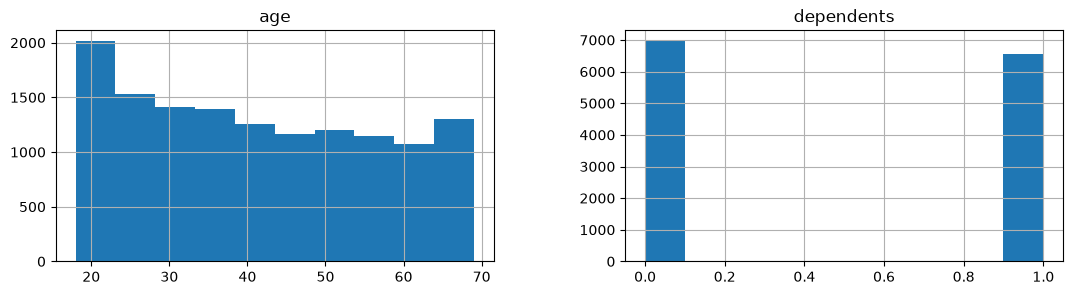

In [10]:
plot_cat_num_target(df_pr, type_f = 'Num', target_dict = None, exclude_cols=['ID', 'score_date'], figsize=(13, 3))

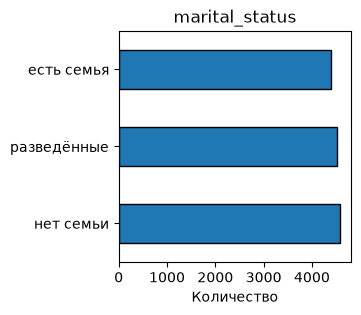

In [11]:
plot_cat_num_target(df_pr, type_f = 'Cat', target_dict = None, exclude_cols=['ID'], figsize=(3, 3), ncols=1)

Заметны пиковые значения на концах для возраста. Фактически рост к краю интервала, что не типично, однако, возможно. `registration_date` - данный признак не должен влиять на целевую переменную, поэтому после некоторых проверок далее удалим его из датасета.

<a id='p5c'></a>

---

### Описание выданного кредита - `ds_15_credit_description.csv`

[К Содержимому проекта](#contents)

In [12]:
df_pr = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')

df_pr = df_pr.rename(columns={'доход':'income', 'сумма_кредита':'loan_amount'})
df = pd.merge(df, df_pr, on = 'ID', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   registration_date  577494 non-null  datetime64[us]
 6   income             577494 non-null  int64         
 7   loan_amount        577494 non-null  int64         
dtypes: datetime64[us](2), int64(4), str(2)
memory usage: 35.2 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

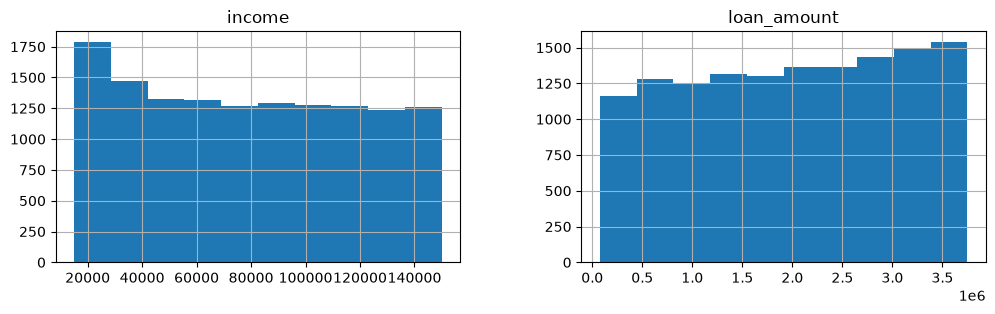

In [13]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(12, 3), ncols=2)

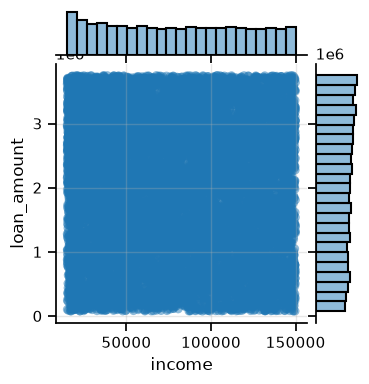

In [14]:
plot_cat_num_target(df_pr, type_f = 'Num', target_dict = {'name_t':'loan_amount', 'type_t':'Num'}, figsize=(10, 4), ncols=1)

В целом выбросов не заметно, аномальным, пожалуй, можно посчитать то, что ярко выраженная связь между суммой кредита и доходом не заметна.

<a id='p5d'></a>

---

### Данные об ипотеке - `ds_15_mortgage_presence.csv`

[К Содержимому проекта](#contents)

In [15]:
df_pr = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')

df_pr = df_pr.rename(columns={'дата_открытия':'opening_date', 'наличие_ипотеки':'mortgage'})
df_pr['opening_date'] = pd.to_datetime(df_pr['opening_date'], format='%Y-%m-%d')
df = pd.merge(df, df_pr, on = 'ID', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   registration_date  577494 non-null  datetime64[us]
 6   income             577494 non-null  int64         
 7   loan_amount        577494 non-null  int64         
 8   opening_date       280733 non-null  datetime64[us]
 9   mortgage           280733 non-null  float64       
dtypes: datetime64[us](3), float64(1), int64(4), str(2)
memory usage: 44.1 MB


#### Пропуски, дубликаты, аномалии

Дубликатов нет. Заметно появление пропусков после соединения таблиц. Столбец `наличие_ипотеки` необходимо заполнить нулем в случае пропуска. В случае столбца `дата_открытия` нужно проверить на аномальные значения.

In [16]:
df[df['registration_date'] == df['opening_date']].shape[0]

280733

**Выводы:** если клиент зарегистрировался в банке, то он открыл ипотеку в этот месяц. Следовательно, можно спокойно заполнять 0 все пропуск в столбце `наличие_ипотеки`. Столбец `дата_открытия` можно удалять.

In [17]:
df = df.drop(columns = ['opening_date', 'registration_date']).copy()
df['mortgage'] = df['mortgage'].fillna(0)
df['mortgage'] = df['mortgage'].astype(int)
display(df.describe().T)

,count,mean,min,25%,50%,75%,max,std
score_date,577494,2017-08-08 08:44:17.407350,2013-01-01 00:00:00,2016-06-01 00:00:00,2017-12-01 00:00:00,2019-01-01 00:00:00,2019-12-01 00:00:00,NaN
age,577494.0,41.395092,18.0,28.0,40.0,54.0,69.0,15.153399
dependents,577494.0,0.484828,0.0,0.0,0.0,1.0,1.0,0.49977
income,577494.0,78778.273305,15010.0,42689.0,77751.0,113707.0,149988.0,40232.320781
loan_amount,577494.0,1989594.30646,75000.0,1078620.0,2029470.0,2910645.0,3749400.0,1061552.204712
mortgage,577494.0,0.486123,0.0,0.0,0.0,1.0,1.0,0.499808


#### Выбросы

Выбросов не замечано.

<a id='p5f'></a>

---

### Макроэкономические показатели `ds_15_macro_data.csv`

[К Содержимому проекта](#contents)

In [18]:
df_pr = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')

df_pr = df_pr.rename(columns={'date':'score_date', 'учетная_ставка':'discount_rate', 
                              'уровень_безработицы' : 'unemployment_rate', 'инфляция':'inflation'})
df_pr['score_date'] = pd.to_datetime(df_pr['score_date'], format='%Y-%m-%d')
df = pd.merge(df, df_pr, on = 'score_date', how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(5), str(2)
memory usage: 48.5 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

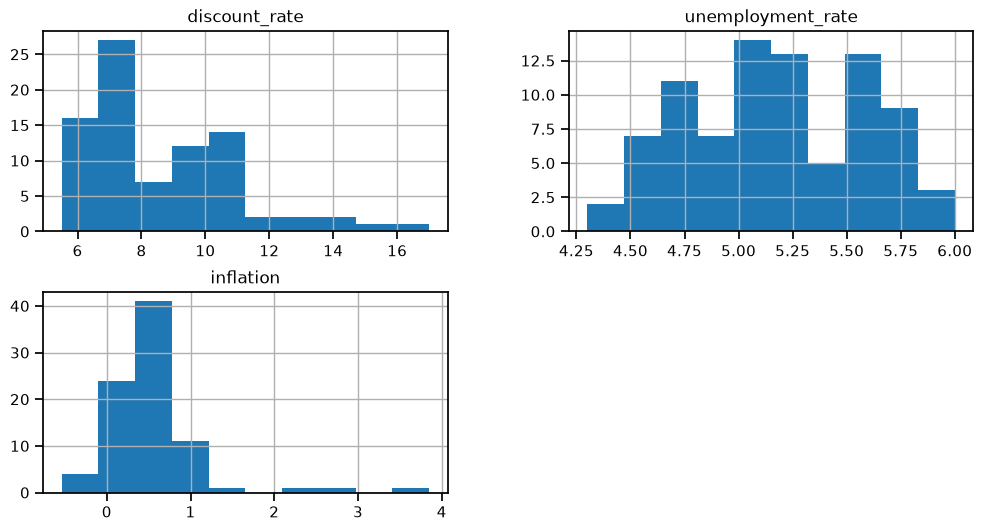

In [19]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(12, 6), ncols=3)

Заметны смещения в значениях, однако, значения в рамках реальных значений (инфляция может быть отрицательной).

<a id='p5e'></a>

---

### Кредитный рейтинг - `ds_15_credit_rating.csv`

[К Содержимому проекта](#contents)

In [20]:
df_pr = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')

df_pr['date'] = pd.to_datetime(df_pr['date'], format='%Y-%m-%d')

df_pr = df_pr.rename(columns={'date':'score_date', 'кредитный_рейтинг':'credit_rating'})
df = pd.merge(df, df_pr, on = ['ID', 'score_date'], how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(6), str(2)
memory usage: 52.9 MB


#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

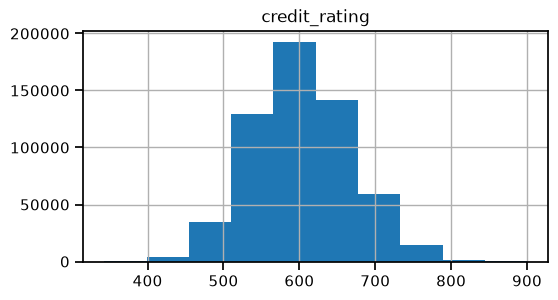

In [21]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(6, 3), ncols=1)

In [22]:
display(df_pr.describe().T)

,count,mean,min,25%,50%,75%,max,std
score_date,577494,2017-08-08 08:44:17.407349,2013-01-01 00:00:00,2016-06-01 00:00:00,2017-12-01 00:00:00,2019-01-01 00:00:00,2019-12-01 00:00:00,NaN
credit_rating,577494.0,603.190961,343.0,558.0,600.0,646.0,900.0,64.358896


Распределение практически нормальное. Ярко выраженных выбросов нет.

<a id='p5g'></a>

---

### Месячные транзакции - `ds_15_transactions.csv`

[К Содержимому проекта](#contents)

In [23]:
df_pr = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

df_pr['date'] = pd.to_datetime(df_pr['date'], format='%Y-%m-%d')

df_pr = df_pr.rename(columns={'date':'score_date', 'MCC_5300':'mcc_5300', 'MCC_5814':'mcc_5814',
                              'MCC_5812':'mcc_5812', 'MCC_5411':'mcc_5411', 'MCC_3990':'mcc_3990',
                              'MCC_5722':'mcc_5722', 'MCC_4900':'mcc_4900', 'MCC_другое':'mcc_other'})
df = pd.merge(df, df_pr, on = ['ID', 'score_date'], how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 20 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
 12  mcc_5300           577494 non-null  float64       
 13  mcc_5814           577494 non-null  float64       
 14 

#### Пропуски, дубликаты

Количество строк не изменилось при присоединении, следовательно, нет пропусков и дубликатов.

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

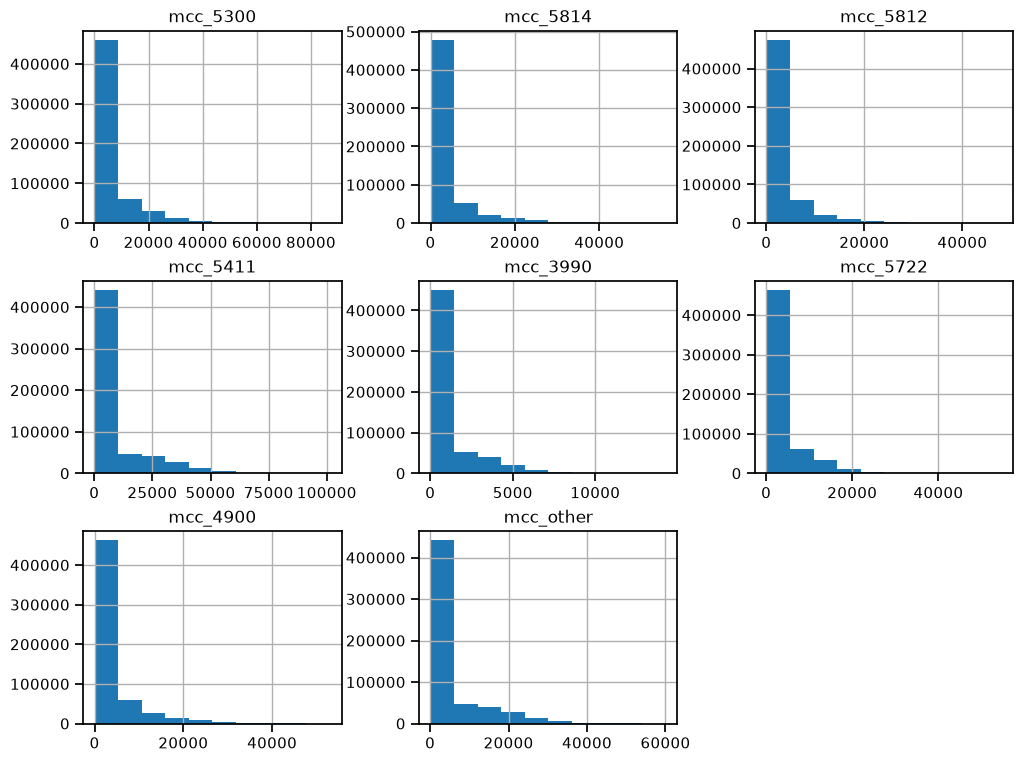

In [24]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(12, 9), ncols=3)

In [25]:
df[df['income'] < df['mcc_5300'] + df['mcc_5814'] + df['mcc_5812'] + df['mcc_5411'] + df['mcc_3990'] + df['mcc_5722'] + df['mcc_4900'] + df['mcc_other']]

,ID,score_date,age,marital_status,dependents,income,loan_amount,mortgage,discount_rate,unemployment_rate,inflation,credit_rating,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_other
7,IDF54896351,2013-10-01,39,нет семьи,1,17633,2506575,1,5.500000,5.4,0.57,670,5122.73,902.46,2841.36,4435.89,421.12,1569.14,1190.45,2522.18
8,IDF54896351,2013-11-01,39,нет семьи,1,17633,2506575,1,5.500000,5.5,0.56,667,5840.47,950.16,2765.82,4591.17,502.54,1627.49,1255.01,2613.11
9,IDF54896351,2013-12-01,39,нет семьи,1,17633,2506575,1,5.500000,5.6,0.51,656,5649.05,959.05,1711.16,4095.09,461.31,1904.80,1240.07,2664.86
13,IDF54896351,2014-04-01,39,нет семьи,1,17633,2506575,1,7.068182,4.9,0.90,675,2994.63,2302.93,1275.00,5474.93,955.62,1905.33,4513.13,3011.57
14,IDF54896351,2014-05-01,39,нет семьи,1,17633,2506575,1,7.500000,5.0,0.90,671,3192.76,3689.33,1312.72,5563.09,1117.07,1926.20,3923.80,3020.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
577459,IDF55151667,2017-02-01,32,разведённые,0,51953,2848485,0,10.000000,5.5,0.22,654,11504.16,3286.15,10075.74,22527.83,1553.69,6265.60,4568.67,11831.07
577460,IDF55151667,2017-03-01,32,разведённые,0,51953,2848485,0,9.943182,5.6,0.13,643,18959.16,3462.52,11832.47,21608.26,1830.63,5940.48,4829.74,9953.81
577461,IDF55151667,2017-04-01,32,разведённые,0,51953,2848485,0,9.750000,5.3,0.33,633,18795.52,3113.61,9309.25,14884.15,1609.56,5986.88,4294.84,9139.55
577462,IDF55151667,2017-05-01,32,разведённые,0,51953,2848485,0,9.250000,5.2,0.37,630,25844.09,4584.75,8891.72,20818.91,2214.44,9603.34,5919.49,13044.96


Заметны месяца для некоторых клиентов в которые они больше тратят чем зарабатывают. Причем таких сочетаний пользователь - месяц достаточно много. В будущем данное наблюдение можно использовать для создания новых признаков. Представленные значения в целом укладываются в разумные значения, без выраженных выбросов.

<a id='p5h'></a>

---

### Данные о просрочках - `ds_15_loan_payment_credit.csv`

[К Содержимому проекта](#contents)

In [26]:
df_pr = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')

df_pr['дата_начала_периода'] = pd.to_datetime(df_pr['дата_начала_периода'], format='%Y-%m-%d')

df_pr = df_pr.rename(columns={'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})
df = pd.merge(df, df_pr, on = ['ID'], how = 'outer')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
 12  mcc_5300           577494 non-null  float64       
 13  mcc_5814           577494 non-null  float64       
 14 

#### Пропуски, дубликаты

Количество строк не изменилось при присоединении следовательно не появляется дубликатов. Пропуски имеются только в столбцах `start_date` и `days_overdue`. Для `days_overdue` логично заполнять пропуски 0, т.к. пользователь не имеет просрочки в днях. `start_date` необходим только для создания целевой переменной, после ее создания он может быть удален, поэтому заполним его флаговой датой, не мешающей заполнению целевой переменной. Например, два века до минимального значения `score_date`.

In [27]:
df['days_overdue'] = df['days_overdue'].fillna(0)
df['days_overdue'] = df['days_overdue'].astype(int)
mindt = df['score_date'].min() - relativedelta(years=200)
df['start_date'] = df['start_date'].fillna(mindt)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 577494 non-null  str           
 1   score_date         577494 non-null  datetime64[us]
 2   age                577494 non-null  int64         
 3   marital_status     577494 non-null  str           
 4   dependents         577494 non-null  int64         
 5   income             577494 non-null  int64         
 6   loan_amount        577494 non-null  int64         
 7   mortgage           577494 non-null  int64         
 8   discount_rate      577494 non-null  float64       
 9   unemployment_rate  577494 non-null  float64       
 10  inflation          577494 non-null  float64       
 11  credit_rating      577494 non-null  int64         
 12  mcc_5300           577494 non-null  float64       
 13  mcc_5814           577494 non-null  float64       
 14 

#### Аномалии и выбросы

Рассмотрим распределения в колонках.

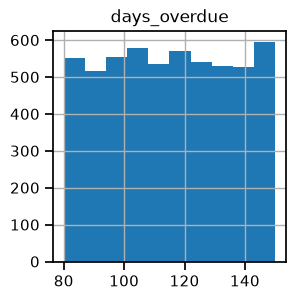

In [28]:
plot_cat_num_target(df_pr, type_f = 'Num', figsize=(3, 3), ncols=3)

In [29]:
display(df_pr.select_dtypes(include=["datetime"]).describe().T)

,count,mean,min,25%,50%,75%,max
start_date,5500,2017-06-15 23:24:54.981818,2013-11-01 00:00:00,2015-12-01 00:00:00,2017-09-01 00:00:00,2019-02-01 00:00:00,2019-12-01 00:00:00


Откровенных выбрасов или аномалий в таблице не заметно. 

<a id='p6a'></a>

---

## Объединение таблиц

Последовательно опишем алгоритм объединения таблиц и сохраним его отдельно. Начнем с алгоритма по формированию целевой переменной.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.
2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.
3. После расчёта целевой переменной удалим строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. У клиента может быть несколько эпизодов с просрочками от 90 дней. Нам нужно взять первый по времени возникновения эпизод в таблице с просрочками. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

[К Содержимому проекта](#contents)

In [30]:
cohort = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')

cohort["score_date"] = pd.to_datetime(cohort["score_date"])
loans["дата_начала_периода"] = pd.to_datetime(loans["дата_начала_периода"])
loans = loans.rename(columns={'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})

loans = loans.loc[loans["days_overdue"] >= 90, ["ID", "start_date"]]
first_default = loans.groupby("ID", as_index=False)["start_date"].min()

cohort = pd.merge(cohort, first_default, how = 'left', on = ['ID'])
cohort = cohort[cohort["start_date"].isna() | (cohort["start_date"] >= cohort["score_date"])].copy()

cohort["target"] = (cohort["start_date"].notna() & 
                    (cohort["start_date"] < cohort["score_date"] +  pd.DateOffset(months=12))).astype(int)
cohort = cohort.sort_values(['score_date', 'ID'])
cohort = cohort.reset_index().drop(columns = ['index'])

print(color.BOLD + color.BLUE + 'Случайные пять строк:' + color.END)
display(cohort.sample(n=10, random_state = random_state))
print(color.BOLD + color.RED + 'Проблемный клиент:' + color.END)
display(cohort[cohort['ID'] == 'IDF55010107'])

print(color.BOLD + color.RED + '\nОсновая информация по датасету:\n' + color.END)
cohort.info()

Случайные пять строк:


,ID,score_date,start_date,target
309549,IDF55141282,2018-09-01,NaT,0
385606,IDF55148143,2019-06-01,NaT,0
91289,IDF55144936,2015-11-01,NaT,0
174723,IDF54961339,2017-03-01,NaT,0
238810,IDF55095653,2017-12-01,NaT,0
200227,IDF54950176,2017-07-01,NaT,0
55022,IDF55010107,2015-03-01,2016-07-01,0
103788,IDF55042264,2016-02-01,NaT,0
80943,IDF55077746,2015-09-01,NaT,0
113542,IDF55024508,2016-04-01,NaT,0


Проблемный клиент:


,ID,score_date,start_date,target
44159,IDF55010107,2014-12-01,2016-07-01,0
47675,IDF55010107,2015-01-01,2016-07-01,0
51287,IDF55010107,2015-02-01,2016-07-01,0
55022,IDF55010107,2015-03-01,2016-07-01,0
58877,IDF55010107,2015-04-01,2016-07-01,0
62818,IDF55010107,2015-05-01,2016-07-01,0
66872,IDF55010107,2015-06-01,2016-07-01,0
71048,IDF55010107,2015-07-01,2016-07-01,0
75308,IDF55010107,2015-08-01,2016-07-01,1
79693,IDF55010107,2015-09-01,2016-07-01,1



Основая информация по датасету:

<class 'pandas.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   ID          438379 non-null  str           
 1   score_date  438379 non-null  datetime64[us]
 2   start_date  62173 non-null   datetime64[us]
 3   target      438379 non-null  int64         
dtypes: datetime64[us](2), int64(1), str(1)
memory usage: 13.4 MB


<a id='p6b'></a>

---

### Создание итоговой таблицы

Опишем итогоую процедуру по созданию датафрейма для обучения, валидации, тестирования и калибровки. При создании будем придерживаться ряда правил:
1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.
>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.
2. Остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента, присоединим без сдвига.
3. Выводы о получившейся таблице будут приведены [далее](#p6d).

[К Содержимому проекта](#contents)

In [31]:
def DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    cohorts["score_date"] = pd.to_datetime(cohorts["score_date"])
    loans["дата_начала_периода"] = pd.to_datetime(loans["дата_начала_периода"])
    loans = loans.rename(columns={'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})
    
    loans = loans.loc[loans["days_overdue"] >= 90, ["ID", "start_date"]]
    first_default = loans.groupby("ID", as_index=False)["start_date"].min()
    cohorts = pd.merge(cohorts, first_default, how = 'left', on = ['ID'])
    cohorts = cohorts[cohorts["start_date"].isna() | (cohorts["start_date"] >= cohorts["score_date"])].copy()
    
    cohorts["target"] = (cohorts["start_date"].notna() & 
                        (cohorts["start_date"] < cohorts["score_date"] + pd.DateOffset(months=12))).astype(int)
    cohorts = cohorts.sort_values(['score_date', 'ID'])
    cohorts = cohorts.reset_index().drop(columns = ['index', 'start_date'])
    
    clients = clients.rename(columns={'возраст':'age', 'семейное_положение':'marital_status', 
                                      'наличие_иждивенцев':'dependents', 'дата_регистрации':'registration_date'})
    clients['registration_date'] = pd.to_datetime(clients['registration_date'], format='%Y-%m-%d')
    
    mortgages = mortgages.rename(columns={'дата_открытия':'opening_date', 'наличие_ипотеки':'mortgage'})
    mortgages['opening_date'] = pd.to_datetime(mortgages['opening_date'], format='%Y-%m-%d')
    
    clients = pd.merge(clients, mortgages, on = 'ID', how = 'left')
    clients = clients.drop(columns = ['opening_date']).copy()
    clients['mortgage'] = clients['mortgage'].fillna(0)
    clients['mortgage'] = clients['mortgage'].astype(int)
    
    credits = credits.rename(columns={'доход':'income', 'сумма_кредита':'loan_amount'})
    clients = pd.merge(clients, credits, on = 'ID', how = 'left')
    cohorts = pd.merge(cohorts, clients, on = 'ID', how = 'left')
    
    # Считаю, что рейтинг актуален на 'date', сдвиг здесь не нужен, т.к. это рейтинг фактически за прошлый месяц
    ratings['date'] = pd.to_datetime(ratings['date'], format='%Y-%m-%d')
    ratings = ratings.rename(columns={'date':'score_date', 'кредитный_рейтинг':'credit_rating'})
    cohorts = pd.merge(cohorts, ratings, on = ['ID', 'score_date'], how = 'left')
    
    macro_data = macro_data.rename(columns={'date':'score_date', 'учетная_ставка':'discount_rate', 
                                            'уровень_безработицы' : 'unemployment_rate', 'инфляция':'inflation'})
    macro_data['score_date'] = pd.to_datetime(macro_data['score_date'], format='%Y-%m-%d')
    
    transactions['date'] = pd.to_datetime(transactions['date'], format='%Y-%m-%d')
    transactions = transactions.rename(columns={'date':'score_date', 'MCC_5300':'mcc_5300', 'MCC_5814':'mcc_5814',
                                                'MCC_5812':'mcc_5812', 'MCC_5411':'mcc_5411', 'MCC_3990':'mcc_3990',
                                                'MCC_5722':'mcc_5722', 'MCC_4900':'mcc_4900', 'MCC_другое':'mcc_other'})
    transactions['score_date'] = (transactions['score_date'].dt.to_period('M') + 1).dt.to_timestamp()
    cohorts = pd.merge(cohorts, macro_data, on = ['score_date'], how = 'left')
    cohorts = pd.merge(cohorts, transactions, on = ['ID', 'score_date'], how = 'left')
    
    # После соединения последний месяц - с пустыми значениями по транзакциям. Добавим флаг - первый месяц клиента, 
    # а пропуски заполним нулем
    cohorts['is_new_client'] = cohorts['mcc_5300'].isna().astype(int)
    cohorts = cohorts.fillna(0)
    
    mxdt = cohorts['score_date'].max() - pd.DateOffset(months=11)
    return cohorts[cohorts['score_date'] < mxdt].copy()

In [32]:
cohorts = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')
clients = pd.read_csv(prefix_str + 'ds_15_client_description.csv')
credits = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')
mortgages = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')
macro_data = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')
ratings = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')
transactions = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

# Тест
df = DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
display(df)
df.info()
display(df.describe().T)

,ID,score_date,target,age,marital_status,dependents,registration_date,mortgage,income,loan_amount,...,inflation,mcc_5300,mcc_5814,mcc_5812,mcc_5411,mcc_3990,mcc_5722,mcc_4900,mcc_other,is_new_client
0,IDF54897139,2013-01-01,1,39,нет семьи,0,2013-01-01,1,88630,3174630,...,0.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1
1,IDF54897415,2013-01-01,0,37,нет семьи,0,2013-01-01,1,118478,1484085,...,0.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1
2,IDF54898248,2013-01-01,0,24,есть семья,1,2013-01-01,1,149716,2326665,...,0.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1
3,IDF54898589,2013-01-01,0,31,разведённые,1,2013-01-01,0,84077,265020,...,0.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1
4,IDF54900261,2013-01-01,0,65,есть семья,0,2013-01-01,1,70568,3656715,...,0.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334691,IDF55151544,2018-12-01,0,51,нет семьи,0,2014-02-01,0,83734,243945,...,0.84,4733.22,857.03,1702.70,3634.25,445.48,1640.79,1129.84,2068.35,0
334692,IDF55151572,2018-12-01,0,59,нет семьи,0,2017-03-01,1,76341,3246930,...,0.84,2935.60,476.27,1417.54,2467.06,273.21,861.51,625.37,1405.17,0
334693,IDF55151575,2018-12-01,0,39,разведённые,0,2014-02-01,1,33773,2624370,...,0.84,825.05,164.84,290.16,756.43,83.04,327.70,218.52,425.66,0
334694,IDF55151608,2018-12-01,0,26,есть семья,0,2016-03-01,0,25427,275175,...,0.84,876.94,134.17,383.38,585.94,63.79,240.22,185.44,362.66,0


<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 23 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   ID                 334696 non-null  str           
 1   score_date         334696 non-null  datetime64[us]
 2   target             334696 non-null  int64         
 3   age                334696 non-null  int64         
 4   marital_status     334696 non-null  str           
 5   dependents         334696 non-null  int64         
 6   registration_date  334696 non-null  datetime64[us]
 7   mortgage           334696 non-null  int64         
 8   income             334696 non-null  int64         
 9   loan_amount        334696 non-null  int64         
 10  credit_rating      334696 non-null  int64         
 11  discount_rate      334696 non-null  float64       
 12  unemployment_rate  334696 non-null  float64       
 13  inflation          334696 non-null  float64       
 14 

,count,mean,min,25%,50%,75%,max,std
score_date,334696,2016-10-26 17:57:19.433994,2013-01-01 00:00:00,2015-10-01 00:00:00,2017-02-01 00:00:00,2018-02-01 00:00:00,2018-12-01 00:00:00,NaN
target,334696.0,0.13255,0.0,0.0,0.0,0.0,1.0,0.339088
age,334696.0,42.79009,18.0,29.0,42.0,56.0,69.0,15.176693
dependents,334696.0,0.495569,0.0,0.0,0.0,1.0,1.0,0.499981
registration_date,334696,2015-01-30 06:50:45.074933,2013-01-01 00:00:00,2013-11-01 00:00:00,2014-11-01 00:00:00,2016-03-01 00:00:00,2018-12-01 00:00:00,NaN
mortgage,334696.0,0.492898,0.0,0.0,0.0,1.0,1.0,0.49995
income,334696.0,80320.946178,15010.0,44857.0,79938.0,114914.0,149981.0,39817.618785
loan_amount,334696.0,1941944.347512,75000.0,1022490.0,1954950.0,2862195.0,3749400.0,1064578.840905
credit_rating,334696.0,618.173665,367.0,571.0,618.0,665.0,900.0,67.080946
discount_rate,334696.0,9.180329,5.5,7.5,9.0,10.690476,17.0,2.137914


**Замечание:**
- `ID` и `registration_date` не были удалены специально с целью дальнейшего использования при создании новых признаков. 
- Исходя из поставленной задачи получается, что в последний год значения целевой переменной могут быть заполнены не корректно: 
    * Условно, у клиента случился дефолт в январе, а данные у нас по декабрь. Это значит, что мы должны были заполнять 1 все последние 12 месяцев, но из-за отсутствия их вместо этого будет везде 1. 
- Для того, чтобы избежать данную ситуацию мы убираем последний год из данных. 

<a id='p6c'></a>

---

### Создание новых признаков

[К Содержимому проекта](#contents)

Основная идея создания новых признаков состоит в следующем. В датафреймы много абсолютных значений (доход, сумма кредита, расходы). Переведем их из абсолютных значений в относительный за счёт нормирования относительно дохода. Таким образ мы будем работать с долями, что может помочь древу решений сопоставлять клиентов с разными уровнями доходов и расходов. Оригинальные признаки будут удалены, кроме дохода клиента, относительно которого и проводилась нормировка. Кроме того, будут добавлены оконные агрегаты (среднее) за последние 2, 3, 6 месяцев по рейтингу и тратам (т.к. именно они зависят от времени; текущий месяц учитывается). Отклонение от среднего за последние месяца может свидетельствовать о том, что у клиента усложнилось финансовые состояние и у него может случится дефолт. Также будет добавлен признак - отношение разности между текущими тратами и тратами в предыдущем месяце, деленные на траты в текущем месяце, и аналогичный ему, но в рамках кредитного рейтинга. Оба показателя могут частично помочь модели определять близкий дефолт. Кроме того, добавим специальный признак, характеризующий количество раз за последние 6 месяцев, когда расходы или рейтинг рос. Они помогают оценивать общий тренд в последнее время. Добавим также дополнительный признак - количество месяцев в течении которых клиент работает с банком (возможно, старые клиенты менее подвержены дефолтам). Итого будут добавлены следующие характеристики:
1. `income_per_dep` - доход на каждого иждивенца.
2. `loan_per_inc` - размер кредита в ежемесячных доходах.
3. `mcc_..._sh` - траты в некоторой категория нормированные через ежемесячный доход.
4. `spendings_sh` - отношение трат к доходам, для линейной модели необходимо его удалить т.к. равен сумме долей `mcc_..._sh`.
5. `spendings_avg...` и `credit_rating_avg...` - средние траты или средний рейтинг за последние ... месяцев. Из-за особенностей расчета Nan не появляется при их вычислении.
6. `spendings_dif1_sh` - разница между предыдущим и текущим месяцом, нормированныая тратами в текущем месяце. 
7. `total_months` - количество месяцев с даты начала работы с банком.
8. `spendings_up_count6` и `credit_rating_up_count6` - признаки для оценки рейтинга за последние 6 месяцев по тратам и рейтингу.

In [33]:
def DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    df = DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
    
    df['income_per_dep'] = df['income'] / (df['dependents'] + 1)
    df['loan_per_inc'] = df['loan_amount'] / df['income_per_dep']
    df['spendings'] = (df['mcc_5300'] + df['mcc_5814'] + df['mcc_5812'] + df['mcc_5411'] + 
                       df['mcc_3990'] + df['mcc_5722'] + df['mcc_4900'] + df['mcc_other'])
    
    df['mcc_5300_sh'] = df['mcc_5300'] / df['income_per_dep']
    df['mcc_5814_sh'] = df['mcc_5814'] / df['income_per_dep']
    df['mcc_5812_sh'] = df['mcc_5812'] / df['income_per_dep']
    df['mcc_5411_sh'] = df['mcc_5411'] / df['income_per_dep']
    df['mcc_3990_sh'] = df['mcc_3990'] / df['income_per_dep']
    df['mcc_5722_sh'] = df['mcc_5722'] / df['income_per_dep']
    df['mcc_4900_sh'] = df['mcc_4900'] / df['income_per_dep']
    df['mcc_other_sh'] = df['mcc_other'] / df['income_per_dep']
    # Для древа решений полезный признак, но для линейных моделей - вредный:
    df['spendings_sh'] = (df['spendings']) / df['income_per_dep']
    for win in [3,4,7]:
        for col in ['spendings', 'credit_rating']:
            avgs = col + '_avg' + str(win-1)
            
            df[avgs] = df.groupby('ID')[col].transform(lambda x: x.rolling(window = win, min_periods=1).mean())
            df[avgs] = df[avgs] / df[col].replace(0, np.nan)
            df[avgs] = df[avgs].fillna(0)
    
    df['spendings_dif1_sh'] = (df['spendings'] - df.groupby('ID')['spendings'].shift(1)) / df['spendings']
    df['spendings_dif1_sh'] = df['spendings_dif1_sh'].fillna(0)
    
    df['credit_rating_dif1_sh'] = (df['credit_rating'] - df.groupby('ID')['credit_rating'].shift(1)) / df['credit_rating']
    df['credit_rating_dif1_sh'] = df['credit_rating_dif1_sh'].fillna(0)
    
    df['spendings_up_count6'] = df.groupby('ID')['spendings'].transform(lambda x: 
                                                                        x.diff().gt(0).rolling(6, min_periods=1).sum())
    
    df['credit_rating_up_count6'] = df.groupby('ID')['credit_rating'].transform(lambda x: 
                                                                                x.diff().gt(0).rolling(6, min_periods=1).sum())
    
    df['total_months'] = (df['score_date'].dt.year  - df['registration_date'].dt.year) * 12 + (df['score_date'].dt.month - df['registration_date'].dt.month)
    
    #Сортировка (на всякий случай). Назначение индекса для дальнейшей работы. Удаление лишних признаков, которые заменили долями
    df = df.sort_values(['score_date', 'ID'])
    df = df.set_index('score_date')
    df = df.drop(columns = ['ID', 'income', 'loan_amount', 'mcc_5300', 'mcc_5814', 'mcc_5812', 'mcc_5411', 'mcc_3990', 
                            'registration_date', 'mcc_5722', 'mcc_4900', 'mcc_other', 'spendings'])
    return df.copy()

In [34]:
cohorts = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')
clients = pd.read_csv(prefix_str + 'ds_15_client_description.csv')
credits = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')
mortgages = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')
macro_data = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')
ratings = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')
transactions = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

# Тест
df = DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
display(df)
df.info()
display(df.describe().T)

,target,age,marital_status,dependents,mortgage,credit_rating,discount_rate,unemployment_rate,inflation,is_new_client,...,credit_rating_avg2,spendings_avg3,credit_rating_avg3,spendings_avg6,credit_rating_avg6,spendings_dif1_sh,credit_rating_dif1_sh,spendings_up_count6,credit_rating_up_count6,total_months
score_date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1,39,нет семьи,0,1,665,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,37,нет семьи,0,1,691,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,24,есть семья,1,1,685,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,31,разведённые,1,0,691,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,65,есть семья,0,1,681,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,0,51,нет семьи,0,0,610,7.625,4.9,0.84,0,...,1.007104,0.914526,1.011885,0.908152,1.017330,-0.108989,0.001639,3.0,3.0,58
2018-12-01,0,59,нет семьи,0,1,591,7.625,4.9,0.84,0,...,1.020305,1.441050,1.035110,5.633417,1.078076,0.180551,-0.018613,2.0,0.0,21
2018-12-01,0,39,разведённые,0,1,599,7.625,4.9,0.84,0,...,0.984975,1.694908,0.982053,1.677160,0.986167,-0.703439,0.015025,2.0,2.0,58


<class 'pandas.DataFrame'>
DatetimeIndex: 334696 entries, 2013-01-01 to 2018-12-01
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   target                   334696 non-null  int64  
 1   age                      334696 non-null  int64  
 2   marital_status           334696 non-null  str    
 3   dependents               334696 non-null  int64  
 4   mortgage                 334696 non-null  int64  
 5   credit_rating            334696 non-null  int64  
 6   discount_rate            334696 non-null  float64
 7   unemployment_rate        334696 non-null  float64
 8   inflation                334696 non-null  float64
 9   is_new_client            334696 non-null  int64  
 10  income_per_dep           334696 non-null  float64
 11  loan_per_inc             334696 non-null  float64
 12  mcc_5300_sh              334696 non-null  float64
 13  mcc_5814_sh              334696 non-null  float64
 14 

,count,mean,std,min,25%,50%,75%,max
target,334696.0,0.132550,0.339088,0.000000,0.000000,0.000000,0.000000,1.000000
age,334696.0,42.790090,15.176693,18.000000,29.000000,42.000000,56.000000,69.000000
dependents,334696.0,0.495569,0.499981,0.000000,0.000000,0.000000,1.000000,1.000000
mortgage,334696.0,0.492898,0.499950,0.000000,0.000000,0.000000,1.000000,1.000000
credit_rating,334696.0,618.173665,67.080946,367.000000,571.000000,618.000000,665.000000,900.000000
discount_rate,334696.0,9.180329,2.137914,5.500000,7.500000,9.000000,10.690476,17.000000
unemployment_rate,334696.0,5.189324,0.359399,4.500000,4.900000,5.200000,5.500000,6.000000
inflation,334696.0,0.488370,0.543756,-0.540000,0.220000,0.400000,0.610000,3.850000
is_new_client,334696.0,0.034697,0.183012,0.000000,0.000000,0.000000,0.000000,1.000000
income_per_dep,334696.0,60324.820512,37294.329109,7511.000000,30470.500000,53234.500000,79614.500000,149981.000000


Для удобства и повторного использования кода сохраним на диск две процедуры, которые из набора датафреймов формирует единый датафрейм для последующего разделения на выборки

In [35]:
feature_builder_code = '''import pandas as pd
import numpy as np

def DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    cohorts["score_date"] = pd.to_datetime(cohorts["score_date"])
    loans["дата_начала_периода"] = pd.to_datetime(loans["дата_начала_периода"])
    loans = loans.rename(columns={'дата_начала_периода':'start_date', 'просрочка_дней':'days_overdue'})
    
    loans = loans.loc[loans["days_overdue"] >= 90, ["ID", "start_date"]]
    first_default = loans.groupby("ID", as_index=False)["start_date"].min()
    cohorts = pd.merge(cohorts, first_default, how = 'left', on = ['ID'])
    cohorts = cohorts[cohorts["start_date"].isna() | (cohorts["start_date"] >= cohorts["score_date"])].copy()
    
    cohorts["target"] = (cohorts["start_date"].notna() & 
                        (cohorts["start_date"] < cohorts["score_date"] + pd.DateOffset(months=12))).astype(int)
    cohorts = cohorts.sort_values(['score_date', 'ID'])
    cohorts = cohorts.reset_index().drop(columns = ['index', 'start_date'])
    
    clients = clients.rename(columns={'возраст':'age', 'семейное_положение':'marital_status', 
                                      'наличие_иждивенцев':'dependents', 'дата_регистрации':'registration_date'})
    clients['registration_date'] = pd.to_datetime(clients['registration_date'], format='%Y-%m-%d')
    
    mortgages = mortgages.rename(columns={'дата_открытия':'opening_date', 'наличие_ипотеки':'mortgage'})
    mortgages['opening_date'] = pd.to_datetime(mortgages['opening_date'], format='%Y-%m-%d')
    
    clients = pd.merge(clients, mortgages, on = 'ID', how = 'left')
    clients = clients.drop(columns = ['opening_date']).copy()
    clients['mortgage'] = clients['mortgage'].fillna(0)
    clients['mortgage'] = clients['mortgage'].astype(int)
    
    credits = credits.rename(columns={'доход':'income', 'сумма_кредита':'loan_amount'})
    clients = pd.merge(clients, credits, on = 'ID', how = 'left')
    cohorts = pd.merge(cohorts, clients, on = 'ID', how = 'left')
    
    # Считаю, что рейтинг актуален на 'date', сдвиг здесь не нужен, т.к. это рейтинг фактически за прошлый месяц
    ratings['date'] = pd.to_datetime(ratings['date'], format='%Y-%m-%d')
    ratings = ratings.rename(columns={'date':'score_date', 'кредитный_рейтинг':'credit_rating'})
    cohorts = pd.merge(cohorts, ratings, on = ['ID', 'score_date'], how = 'left')
    
    macro_data = macro_data.rename(columns={'date':'score_date', 'учетная_ставка':'discount_rate', 
                                            'уровень_безработицы' : 'unemployment_rate', 'инфляция':'inflation'})
    macro_data['score_date'] = pd.to_datetime(macro_data['score_date'], format='%Y-%m-%d')
    
    transactions['date'] = pd.to_datetime(transactions['date'], format='%Y-%m-%d')
    transactions = transactions.rename(columns={'date':'score_date', 'MCC_5300':'mcc_5300', 'MCC_5814':'mcc_5814',
                                                'MCC_5812':'mcc_5812', 'MCC_5411':'mcc_5411', 'MCC_3990':'mcc_3990',
                                                'MCC_5722':'mcc_5722', 'MCC_4900':'mcc_4900', 'MCC_другое':'mcc_other'})
    transactions['score_date'] = (transactions['score_date'].dt.to_period('M') + 1).dt.to_timestamp()
    cohorts = pd.merge(cohorts, macro_data, on = ['score_date'], how = 'left')
    cohorts = pd.merge(cohorts, transactions, on = ['ID', 'score_date'], how = 'left')
    
    # После соединения последний месяц - с пустыми значениями по транзакциям. Добавим флаг - первый месяц клиента, 
    # а пропуски заполним нулем
    cohorts['is_new_client'] = cohorts['mcc_5300'].isna().astype(int)
    cohorts = cohorts.fillna(0)
    
    mxdt = cohorts['score_date'].max() - pd.DateOffset(months=11)
    return cohorts[cohorts['score_date'] < mxdt].copy()

def DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts):
    df = DataFrame_Creation(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
    
    df['income_per_dep'] = df['income'] / (df['dependents'] + 1)
    df['loan_per_inc'] = df['loan_amount'] / df['income_per_dep']
    df['spendings'] = (df['mcc_5300'] + df['mcc_5814'] + df['mcc_5812'] + df['mcc_5411'] + 
                       df['mcc_3990'] + df['mcc_5722'] + df['mcc_4900'] + df['mcc_other'])
    
    df['mcc_5300_sh'] = df['mcc_5300'] / df['income_per_dep']
    df['mcc_5814_sh'] = df['mcc_5814'] / df['income_per_dep']
    df['mcc_5812_sh'] = df['mcc_5812'] / df['income_per_dep']
    df['mcc_5411_sh'] = df['mcc_5411'] / df['income_per_dep']
    df['mcc_3990_sh'] = df['mcc_3990'] / df['income_per_dep']
    df['mcc_5722_sh'] = df['mcc_5722'] / df['income_per_dep']
    df['mcc_4900_sh'] = df['mcc_4900'] / df['income_per_dep']
    df['mcc_other_sh'] = df['mcc_other'] / df['income_per_dep']
    # Для древа решений полезный признак, но для линейных моделей - вредный:
    df['spendings_sh'] = (df['spendings']) / df['income_per_dep']
    for win in [3,4,7]:
        for col in ['spendings', 'credit_rating']:
            avgs = col + '_avg' + str(win-1)
            
            df[avgs] = df.groupby('ID')[col].transform(lambda x: x.rolling(window = win, min_periods=1).mean())
            df[avgs] = df[avgs] / df[col].replace(0, np.nan)
            df[avgs] = df[avgs].fillna(0)
    
    df['spendings_dif1_sh'] = (df['spendings'] - df.groupby('ID')['spendings'].shift(1)) / df['spendings']
    df['spendings_dif1_sh'] = df['spendings_dif1_sh'].fillna(0)
    
    df['credit_rating_dif1_sh'] = (df['credit_rating'] - df.groupby('ID')['credit_rating'].shift(1)) / df['credit_rating']
    df['credit_rating_dif1_sh'] = df['credit_rating_dif1_sh'].fillna(0)
    
    df['spendings_up_count6'] = df.groupby('ID')['spendings'].transform(lambda x: 
                                                                        x.diff().gt(0).rolling(6, min_periods=1).sum())
    
    df['credit_rating_up_count6'] = df.groupby('ID')['credit_rating'].transform(lambda x: 
                                                                                x.diff().gt(0).rolling(6, min_periods=1).sum())
    
    df['total_months'] = (df['score_date'].dt.year  - df['registration_date'].dt.year) * 12 + (df['score_date'].dt.month - df['registration_date'].dt.month)
    
    #Сортировка (на всякий случай). Назначение индекса для дальнейшей работы. Удаление лишних признаков, которые заменили долями
    df = df.sort_values(['score_date', 'ID'])
    df = df.set_index('score_date')
    df = df.drop(columns = ['ID', 'income', 'loan_amount', 'mcc_5300', 'mcc_5814', 'mcc_5812', 'mcc_5411', 'mcc_3990', 
                            'registration_date', 'mcc_5722', 'mcc_4900', 'mcc_other', 'spendings'])
    return df.copy()
'''
# Запись подпрограммы
try:
    feature_builder = "../src/feature_builder.py"
    with open(feature_builder, "w", encoding="utf-8") as f:
        f.write(feature_builder_code)
    
except Exception:
    feature_builder = "feature_builder.py"
    with open(feature_builder, "w", encoding="utf-8") as f:
        f.write(feature_builder_code)

# Считывание подпрограммы
try:
    sys.path.append("../src")
    from feature_builder import DataFrame_Creation_New_Features
except Exception:
    from feature_builder import DataFrame_Creation_New_Features

# Тест
cohorts = pd.read_csv(prefix_str + 'ds_15_cohort_grid.csv')
loans = pd.read_csv(prefix_str + 'ds_15_loan_payment_credit.csv')
clients = pd.read_csv(prefix_str + 'ds_15_client_description.csv')
credits = pd.read_csv(prefix_str + 'ds_15_credit_description.csv')
mortgages = pd.read_csv(prefix_str + 'ds_15_mortgage_presence.csv')
macro_data = pd.read_csv(prefix_str + 'ds_15_macro_data.csv')
ratings = pd.read_csv(prefix_str + 'ds_15_credit_rating.csv')
transactions = pd.read_csv(prefix_str + 'ds_15_transactions.csv')

df = DataFrame_Creation_New_Features(loans, transactions, clients, credits, mortgages, ratings, macro_data, cohorts)
display(df)
df.info()
display(df.describe().T)

,target,age,marital_status,dependents,mortgage,credit_rating,discount_rate,unemployment_rate,inflation,is_new_client,...,credit_rating_avg2,spendings_avg3,credit_rating_avg3,spendings_avg6,credit_rating_avg6,spendings_dif1_sh,credit_rating_dif1_sh,spendings_up_count6,credit_rating_up_count6,total_months
score_date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,1,39,нет семьи,0,1,665,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,37,нет семьи,0,1,691,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,24,есть семья,1,1,685,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,31,разведённые,1,0,691,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
2013-01-01,0,65,есть семья,0,1,681,5.500,5.7,0.97,1,...,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-01,0,51,нет семьи,0,0,610,7.625,4.9,0.84,0,...,1.007104,0.914526,1.011885,0.908152,1.017330,-0.108989,0.001639,3.0,3.0,58
2018-12-01,0,59,нет семьи,0,1,591,7.625,4.9,0.84,0,...,1.020305,1.441050,1.035110,5.633417,1.078076,0.180551,-0.018613,2.0,0.0,21
2018-12-01,0,39,разведённые,0,1,599,7.625,4.9,0.84,0,...,0.984975,1.694908,0.982053,1.677160,0.986167,-0.703439,0.015025,2.0,2.0,58


<class 'pandas.DataFrame'>
DatetimeIndex: 334696 entries, 2013-01-01 to 2018-12-01
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   target                   334696 non-null  int64  
 1   age                      334696 non-null  int64  
 2   marital_status           334696 non-null  str    
 3   dependents               334696 non-null  int64  
 4   mortgage                 334696 non-null  int64  
 5   credit_rating            334696 non-null  int64  
 6   discount_rate            334696 non-null  float64
 7   unemployment_rate        334696 non-null  float64
 8   inflation                334696 non-null  float64
 9   is_new_client            334696 non-null  int64  
 10  income_per_dep           334696 non-null  float64
 11  loan_per_inc             334696 non-null  float64
 12  mcc_5300_sh              334696 non-null  float64
 13  mcc_5814_sh              334696 non-null  float64
 14 

,count,mean,std,min,25%,50%,75%,max
target,334696.0,0.132550,0.339088,0.000000,0.000000,0.000000,0.000000,1.000000
age,334696.0,42.790090,15.176693,18.000000,29.000000,42.000000,56.000000,69.000000
dependents,334696.0,0.495569,0.499981,0.000000,0.000000,0.000000,1.000000,1.000000
mortgage,334696.0,0.492898,0.499950,0.000000,0.000000,0.000000,1.000000,1.000000
credit_rating,334696.0,618.173665,67.080946,367.000000,571.000000,618.000000,665.000000,900.000000
discount_rate,334696.0,9.180329,2.137914,5.500000,7.500000,9.000000,10.690476,17.000000
unemployment_rate,334696.0,5.189324,0.359399,4.500000,4.900000,5.200000,5.500000,6.000000
inflation,334696.0,0.488370,0.543756,-0.540000,0.220000,0.400000,0.610000,3.850000
is_new_client,334696.0,0.034697,0.183012,0.000000,0.000000,0.000000,0.000000,1.000000
income_per_dep,334696.0,60324.820512,37294.329109,7511.000000,30470.500000,53234.500000,79614.500000,149981.000000


<a id='p6d'></a>

---

### Проверка на корреляцию

[К Содержимому проекта](#contents)

In [36]:
def plot_heatmap(data,title,xlabel,ylabel,figsize = (4,4)):
    plt.figure(figsize=figsize)
    fig = sns.heatmap(data,
                      annot=True, # Отображаем численные значения в ячейках карты
                      fmt='.2f', # Форматируем значения корреляции: два знака после точки
                      cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
                      linewidths=0.5, # Форматируем линию между ячейками карты
                      cbar=False # Отключаем цветовую шкалу
                      ,annot_kws={'size': 8}
                      ,mask = np.triu(np.ones_like(data, dtype=bool))
                     )
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=10)
    plt.ylabel(ylabel, fontsize=10)

    fig.tick_params(axis='both', labelsize=8)    
    
    plt.show()

In [37]:
num_cols = list(df.select_dtypes(include=['int', 'float']).columns)
cat_cols = list(df.select_dtypes(include=["object", "string", "category"]).columns)

correlation_matrix_phik = df.phik_matrix(interval_cols = num_cols)
correlation_matrix_pearson = df[num_cols].corr(method='pearson')
correlation_matrix_spearman = df[num_cols].corr(method='spearman')

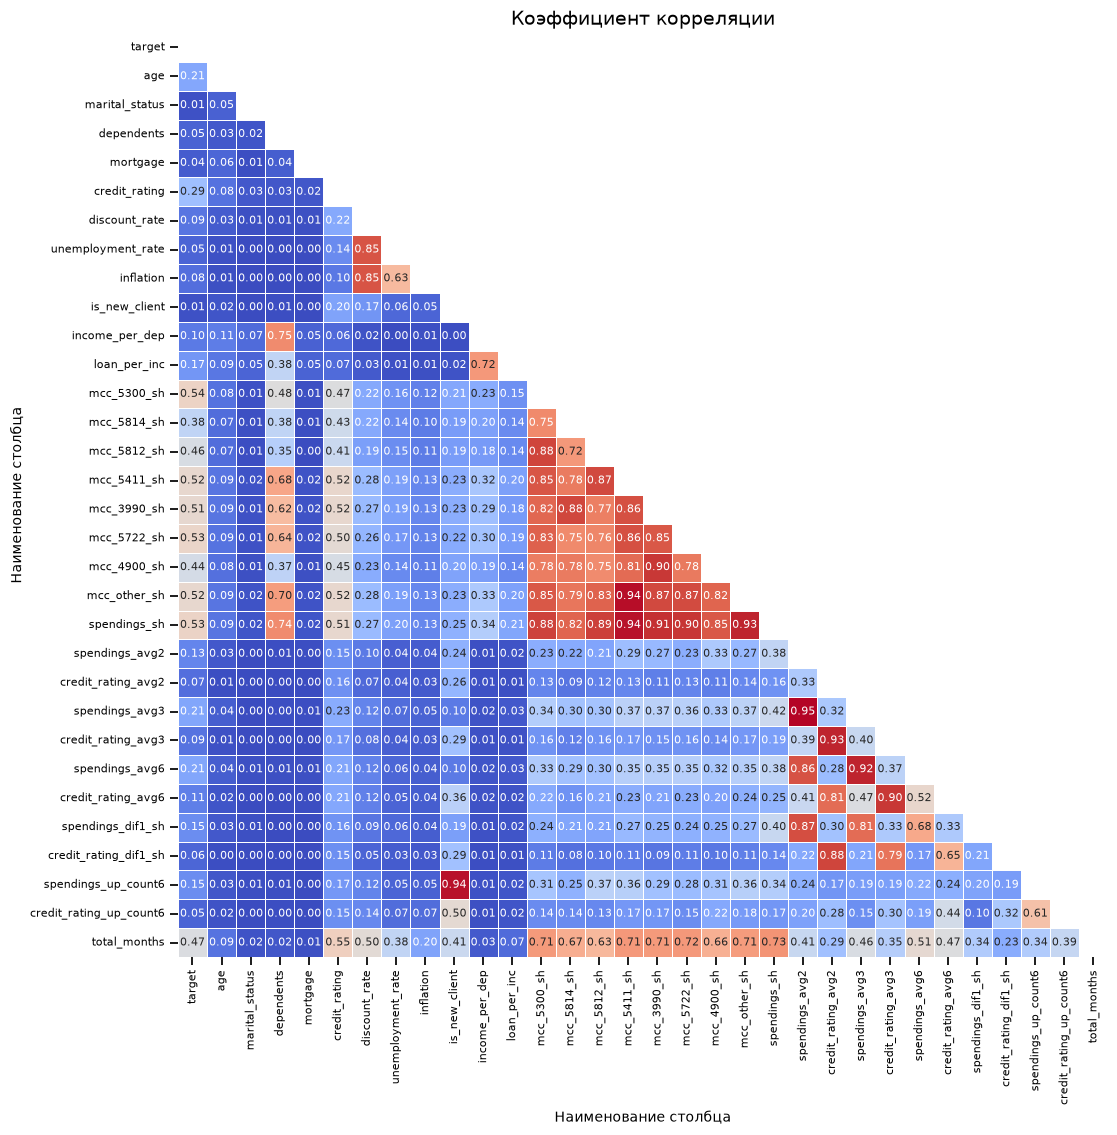

In [38]:
plot_heatmap(correlation_matrix_phik,'Коэффициент корреляции','Наименование столбца'
             ,'Наименование столбца',figsize = (12,12))

Кроме того, проверим на мультиколлинеарность. Для проверки на мультиколлинеарность используется коэффициент variance_inflation_factor (VIF). В рамках данного коэффициент для каждого признака строится регрессия этого признака на все остальные признаки. Если остальные признаки хорошо объясняют его значение, VIF получается большим - это признак мультиколлинеарности.

У VIF есть формула: $ \text{VIF} = \frac{1}{1-R^2_i}$. Здесь $R^2_i$ - коэффициент детерминации при регрессии i-го признака на все остальные признаки.

Традиционно, показатель значения показателя оценивают примерно так: 
- VIF $\approx$ 1 - мультиколлинеарности практически нет
- VIF $\in(1,5)$ допустимый уровень
- VIF $\in[5,10]$ заметная мультиколлинеарность
- VIF > 10 сильная мультиколлинеарность

In [39]:
Xpr = df.drop(columns=['target','spendings_sh'] + cat_cols).copy()
Xpr = add_constant(Xpr)
vif = pd.DataFrame({
    'feature': Xpr.columns,
    'VIF': [
        variance_inflation_factor(Xpr.values, i)
        for i in range(Xpr.shape[1])
    ]
})
vif = vif.sort_values('VIF', ascending=False)
display(vif)

,feature,VIF
0,const,40513.649719
14,mcc_5411_sh,82.517711
15,mcc_3990_sh,57.189163
18,mcc_other_sh,48.340247
13,mcc_5812_sh,31.268853
22,credit_rating_avg3,30.108839
20,credit_rating_avg2,26.733418
21,spendings_avg3,20.396019
19,spendings_avg2,18.742040
12,mcc_5814_sh,17.016336


<span style="font-size: 16px;">**Выводы**</span>

Для оценки попарной корреляции использовался коэффициент $\phi_k$. На таргет достаточно сильно влияют расходы, стаж клиента (что немного неожиданно), возраст, кредитный рейтинг. Наиболее сильную попарную связь между признаками демонстрируют статьи расходов в предыдущем месяце, что в принципе логично. Их связь с кредитным рейтингом тоже ожидаема, т.к. сам рейтинг есть производная от них в том числе. В рамках проверки линейной зависимости признаков через VIF необходимо удалить `spendings_sh`, иначе он будет коллинеарен сумме расходов по категориям.

<a id='p6e'></a>

---

### Анализ итоговой таблицы (выводы по EDA)

1. Проведем краткий анализ получившейся итоговой таблицы.
2. Сделаем вывод о данных для моделирования.
3. Проверим целевую переменную на предмет дисбаланса классов. Сделаем выводы.

[К Содержимому проекта](#contents)

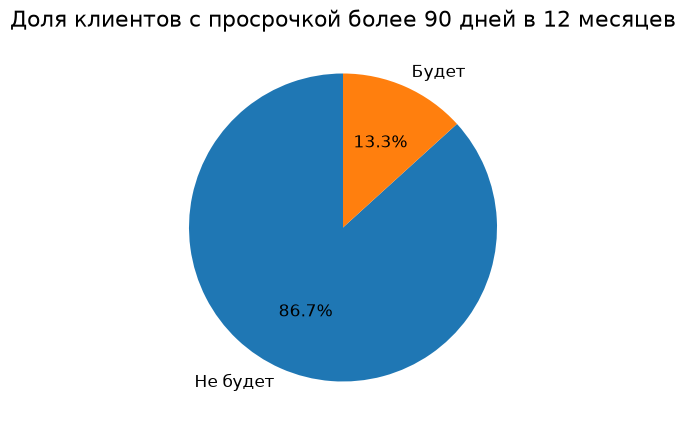

In [40]:
grouped = df.groupby('target')['age'].count().reset_index().sort_values(by = 'age',ascending=False)
grouped.index = ['Не будет' , 'Будет']
grouped['age'] = round(100*grouped['age']/sum(grouped['age']),2)

fig = grouped['age'].plot.pie(figsize = (5,5),autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'color': 'black'})

plt.title('Доля клиентов с просрочкой более 90 дней в 12 месяцев', fontsize=16)
plt.ylabel('')
plt.show()

<span style="font-size: 16px;">**Выводы**</span>

Проведенный исследовательский анализ позволил оценить структуру, качество и особенности подготовленного набора данных. Исходные данные из восьми таблиц были последовательно объединены с учетом временной структуры наблюдений. Целевая переменная сформирована для каждой пары «клиент - месяц»: значение 1 соответствует возникновению просрочки более 90 дней в течение следующих 12 месяцев, значение 0 - ее отсутствию.

Итоговый датафрейм содержит 334696 наблюдений и 32 признака за период с января 2013 по декабрь 2018 года (данные за 2019 год были удалены, т.к. для них построение целевой переменной будет некорректно с учетом горизонта прогнозирования - 12 месяцев). В данных отсутствуют пропуски и дубликаты. Выбросы и аномалии, не соответствующие предметной области, также не выявлены. В ходе подготовки были сформированы относительные и временные признаки, позволяющие учитывать финансовую нагрузку клиента, структуру расходов и динамику расходов и кредитного рейтинга. Были созданы специальные процедуры, позволяющие собрать восемь датасетов в один и сформировать данные для обучения, валидации, калибровки и тестирования модели.

Целевая переменная имеет выраженный дисбаланс классов: положительный класс составляет около 13,3% наблюдений. Это необходимо учитывать при построении моделей, поэтому на этапе моделирования будут рассмотрены различные методы балансировки классов. Наиболее сильное влияние на целевую переменную согласно коэффициенту корреляции $\phi_k$ являются признаки, описывающие траты в прошлом месяце, стаж клиента в банке (количество месяцов с оказания первой услуги или покупки первого продукта у банка), возраст, кредитный рейтинг.

Кроме того, поскольку каждое наблюдение относится к конкретному моменту времени, при разделении данных и кросс-валидации необходимо сохранять временной порядок и исключать использование информации из будущего. Это позволит корректно оценить способность модели прогнозировать будущую просрочку и избежать временной утечки данных.

<a id='p7a'></a>

---

## Моделирование

1. Подготовим обучающую, калибровочную и тестовую выборки (тестовая 12 месяцев, калибровочную из 12 месяцев также разделим на две, одна - для обучения калибратора, а вторая для тестирования калибровки). Кросс-валидация будет осуществляться на трех фолдах.
2. Для категориального признака применим OneHotEncoder в рамках pipeline.
3. Обучим базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели - логистическую регрессию и случайный лес - без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Для каждой из типов моделей с балансировкой выберем лучшую модель.
4. Случайный лес с настройками по умолчанию легко переобучается. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации. Чтобы исправить проблемы модели Random Forest, подберем для неё гиперпараметры с помощью Optuna. Для оптимизации используем метрику `missed defaults rate`.
5. Сравним все полученные модели.
6. Для оценки моделей используем метрики:
   * accuracy, ROC-AUC
   * approval rate,
   * default rate,
   * missed defaults rate,
   * а также вспомогательные технический PR-AUC.
7. Сделаем вывод о работе, проделанной в этом разделе.

---

### Логистическая регрессия

[К Содержимому проекта](#contents)

Сначала выделим выборки для обучения, калибровки и тестирования. А также опишем подпрограммы для расчета метрик у некоторой модели.

In [41]:
# Разделение выборок
mxdt = df.index[-1]
mxdt1 = mxdt - relativedelta(months=11)
df_test = df.loc[mxdt1:].copy()
mxdt1 = mxdt - relativedelta(months=12)
df_train_val_cal = df.loc[:mxdt1]

mxdt = df_train_val_cal.index[-1]
mxdt1 = mxdt - relativedelta(months=11)
df_cal = df_train_val_cal.loc[mxdt1:].copy()
mxdt1 = mxdt - relativedelta(months=12)
df_train_val = df_train_val_cal.loc[:mxdt1].copy()

mxdt = df_cal.index[-1]
mxdt1 = mxdt - relativedelta(months=5)
df_cal_val = df_cal.loc[mxdt1:].copy()
mxdt1 = mxdt - relativedelta(months=6)
df_cal_train = df_cal.loc[:mxdt1].copy()

X_train_val = df_train_val.drop(columns = ['target']).copy()
y_train_val = df_train_val['target']

X_cal = df_cal.drop(columns = ['target']).copy()
y_cal = df_cal['target']

X_test = df_test.drop(columns = ['target']).copy()
y_test = df_test['target']

X_cal_train = df_cal_train.drop(columns = ['target']).copy()
y_cal_train = df_cal_train['target']

X_cal_val = df_cal_val.drop(columns = ['target']).copy()
y_cal_val = df_cal_val['target']

<span style="font-size: 16px;">**Подпрограммы для вычисления бизнесовых метрик и кросс-валидации.**</span>

In [42]:
def approval_rate(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    TN = ((y_true == 0) & (y_pred == 0)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    return float((TN + FN) / y_true.shape[0])

def default_rate(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    TN = ((y_true == 0) & (y_pred == 0)).sum()
    FN = ((y_true == 1) & (y_pred == 0)).sum()
    return float(FN / (TN + FN))
    
def missed_defaults_rate(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    return float(1.0 - recall_score(y_true, y_pred))

def metrics_dict_calc(y_true, y_pred_proba, cutoff = 0.5):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    return {
        'approval_rate' : approval_rate(y_true, y_pred_proba, cutoff),
        'default_rate' : default_rate(y_true, y_pred_proba, cutoff),
        'missed_defaults_rate' : missed_defaults_rate(y_true, y_pred_proba, cutoff),
        'accuracy' : accuracy_score(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_pred_proba),
        'pr_auc' : average_precision_score(y_true, y_pred_proba)
    }

def TimeSeriesCrossVal(model, gtscv, groups, X_train_val, y_train_val, model_name = 'Unknown'):
    met_list = ['approval_rate', 'default_rate', 'missed_defaults_rate', 'accuracy', 'roc_auc', 'pr_auc']
    
    cv_met = {}
    for met in met_list:
        cv_met[f'{met}_tra'] = []
        cv_met[f'{met}_val'] = []
    
    for i, (train_idx, val_idx) in enumerate(gtscv.split(X_train_val, y_train_val, groups=groups)):
        X_train = X_train_val.iloc[train_idx].copy()
        y_train = y_train_val.iloc[train_idx].copy()
        
        X_val = X_train_val.iloc[val_idx].copy()
        y_val = y_train_val.iloc[val_idx].copy()
        
        model.fit(X_train,y_train)
        y_pred_proba = model.predict_proba(X_train)[:,1]
        metrics = metrics_dict_calc(y_train, y_pred_proba)
        for met in met_list:
            cv_met[f'{met}_tra'].append(metrics[met])
        
        y_pred_proba = model.predict_proba(X_val)[:,1]
        metrics = metrics_dict_calc(y_val, y_pred_proba)
        for met in met_list:
            cv_met[f'{met}_val'].append(metrics[met])
    
    cv_met_all = {'model_name': [model_name, model_name], 'fold_name' : ['train', 'val']}
    for met in met_list:
        cv_met_all[met] = []
    
    for suf in ['_tra', '_val']:
        for met in met_list:
            avg = round(pd.Series(cv_met[met + suf]).mean(),3)
            std = round(pd.Series(cv_met[met + suf]).std(),3)
            
            cv_met_all[met].append(f'{avg} ± {std}')
    
    
    return cv_met_all

<span style="font-size: 16px;">**Пайплайн логистической регрессии:**</span>

In [43]:
# Pipeline для категориальных признаков с малым количеством категорий
ohe_l = X_train_val.select_dtypes(include=["str", "object", "category"]).columns.tolist()
ohe_pip = Pipeline([ ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')) ])
# для платформы так ('ohe', OneHotEncoder(sparse=False, handle_unknown='ignore'))

# Pipeline для числовых признаков с масштабированием
num_l = [col for col in X_train_val.select_dtypes(include=["float","int"]).columns 
         if col != 'spendings_sh']
num_pip = Pipeline([ ('standard', StandardScaler()) ])


# ColumnTransformer для всех колонок
line_preprocessor = ColumnTransformer(
    transformers=[('cat_ohe', ohe_pip, ohe_l),
                  ('num_standard', num_pip, num_l) 
                 ])

<span style="font-size: 16px;">**Перебор разных стратегий по борьбе с дисбалансом классов**</span>

In [44]:
# Выделение групп из трайна
miny = min(X_train_val.index).year
groups = (X_train_val.reset_index()['score_date'].dt.year - miny) * 12 + X_train_val.reset_index()['score_date'].dt.month

# Создаем параметры разбиения
cv_args = {
    "test_size": 12,          # валидация - 12 месяцев
#    "train_size": 23,         # train - 23 месяца, только для rolling
    "n_splits": 3,            # это для expanding
    "gap_size": 0,            # без разрыва между train и val
    "shift_size": 12,         # сдвиг между фолдами - 12 месяцев
    "window_type": "expanding"# окно расширяется expanding, альтернатива rolling
}
gtscv = GroupTimeSeriesSplit(**cv_args)

In [45]:
#Pipeline для перебора:
pipelines = {
    'LogReg': Pipeline([('preprocessing', line_preprocessor), 
                        ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_balanced': Pipeline([('preprocessing', line_preprocessor), 
                                 ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000, class_weight='balanced'))]),
    'LogReg_over_1': ImbPipeline([('preprocessing', line_preprocessor),
                                  ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_over_05': ImbPipeline([('preprocessing', line_preprocessor),
                                   ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 0.5)),
                                   ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_over_smote': ImbPipeline([('preprocessing', line_preprocessor),
                                      ('over_smote', SMOTE(random_state=random_state)),
                                      ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_under_1': ImbPipeline([('preprocessing', line_preprocessor),
                                  ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_under_05': ImbPipeline([('preprocessing', line_preprocessor),
                                    ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 0.5)),
                                    ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_mixed': ImbPipeline([('preprocessing', line_preprocessor),
                                 ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 0.3)),
                                 ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                 ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))])
}

lin_df = pd.DataFrame()
for name, model in pipelines.items():
    pr_df = pd.DataFrame(TimeSeriesCrossVal(model, gtscv, groups, X_train_val, y_train_val, name))
    lin_df = pd.concat([lin_df, pr_df], axis=0, ignore_index=True)

In [46]:
display(lin_df.sort_values(by = ['fold_name', 'missed_defaults_rate']))

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,pr_auc
10,LogReg_under_1,train,0.586 ± 0.008,0.088 ± 0.016,0.26 ± 0.037,0.681 ± 0.005,0.771 ± 0.022,0.422 ± 0.018
4,LogReg_over_1,train,0.589 ± 0.013,0.088 ± 0.016,0.261 ± 0.037,0.683 ± 0.004,0.772 ± 0.021,0.424 ± 0.016
2,LogReg_balanced,train,0.589 ± 0.014,0.088 ± 0.016,0.261 ± 0.038,0.683 ± 0.004,0.772 ± 0.021,0.423 ± 0.017
8,LogReg_over_smote,train,0.589 ± 0.012,0.088 ± 0.016,0.263 ± 0.038,0.683 ± 0.004,0.771 ± 0.022,0.424 ± 0.018
14,LogReg_mixed,train,0.589 ± 0.012,0.088 ± 0.016,0.263 ± 0.039,0.682 ± 0.004,0.771 ± 0.022,0.423 ± 0.017
12,LogReg_under_05,train,0.812 ± 0.017,0.139 ± 0.016,0.573 ± 0.043,0.783 ± 0.006,0.772 ± 0.022,0.427 ± 0.017
6,LogReg_over_05,train,0.814 ± 0.021,0.139 ± 0.015,0.575 ± 0.048,0.784 ± 0.008,0.772 ± 0.022,0.427 ± 0.017
0,LogReg,train,0.949 ± 0.01,0.178 ± 0.013,0.859 ± 0.02,0.808 ± 0.014,0.772 ± 0.021,0.43 ± 0.017
5,LogReg_over_1,val,0.573 ± 0.168,0.061 ± 0.026,0.198 ± 0.038,0.678 ± 0.123,0.795 ± 0.084,0.394 ± 0.031
15,LogReg_mixed,val,0.581 ± 0.176,0.058 ± 0.017,0.198 ± 0.066,0.688 ± 0.121,0.801 ± 0.074,0.398 ± 0.024


В целом, согласно полученным метрикам по кросс-валидации возьмем следующие модели: 
- `LogReg_mixed` - линейная модель с уменьшением количества наблюдений для можеритарного класса и увеличением количества минорного класса до 1 к 1.
- `LogReg` - линейная модель без балансировки классов.

Подобный выбор определяется значением метрики `missed_defaults_rate` на валидационной выборке. Эти модели полярны друг к другу, одна осторожна (`LogReg_mixed`) и часто предупреждает о дефолте там, где его возможно и нет, но при этом достаточно часто находит настоящие дефолты. А `LogReg` редко предупреждает о возможном дефолте клиента. Выбор именно `LogReg_mixed` обусловлен его большей универсальностью, она с одной стороны немного увеличивает количество строк с положительным классом и уменьшает количество нулевого класса.

<a id='p7b'></a>

---

### Случайный лес

[К Содержимому проекта](#contents)

In [47]:
# Pipeline для категориальных признаков с малым количеством категорий
ohe_rf = X_train_val.select_dtypes(include=["str", "object", "category"]).columns.tolist()
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# для платформы так ('ohe', OneHotEncoder(sparse=False, handle_unknown='ignore'))

# Pipeline для числовых признаков с масштабированием
num_rf = X_train_val.select_dtypes(include=["float","int"]).columns.tolist()

# ColumnTransformer для всех колонок
rf_preprocessor = ColumnTransformer(
    transformers=[('cat_ohe', ohe, ohe_rf)],
    remainder='passthrough')

In [48]:
#Pipeline для перебора:
pipelines = {
    'RanFor': Pipeline([('preprocessing', rf_preprocessor), 
                        ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_balanced': Pipeline([('preprocessing', rf_preprocessor), 
                                 ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state, class_weight='balanced'))]),
    'RanFor_over_1': ImbPipeline([('preprocessing', rf_preprocessor),
                                  ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_over_05': ImbPipeline([('preprocessing', rf_preprocessor),
                                   ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 0.5)),
                                   ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_over_smote': ImbPipeline([('preprocessing', rf_preprocessor),
                                      ('over_smote', SMOTE(random_state=random_state)),
                                      ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_under_1': ImbPipeline([('preprocessing', rf_preprocessor),
                                  ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_under_05': ImbPipeline([('preprocessing', rf_preprocessor),
                                    ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 0.5)),
                                    ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_mixed': ImbPipeline([('preprocessing', line_preprocessor),
                                 ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 0.3)),
                                 ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                 ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))])
}

rf_df = pd.DataFrame()
for name, model in pipelines.items():
    pr_df = pd.DataFrame(TimeSeriesCrossVal(model, gtscv, groups, X_train_val, y_train_val, name))
    rf_df = pd.concat([rf_df, pr_df], axis=0, ignore_index=True)

In [49]:
display(rf_df.sort_values(by = ['fold_name', 'missed_defaults_rate']))

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,pr_auc
0,RanFor,train,0.803 ± 0.016,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
2,RanFor_balanced,train,0.803 ± 0.016,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
4,RanFor_over_1,train,0.803 ± 0.016,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
6,RanFor_over_05,train,0.803 ± 0.016,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
8,RanFor_over_smote,train,0.803 ± 0.016,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
10,RanFor_under_1,train,0.626 ± 0.007,0.0 ± 0.0,0.0 ± 0.0,0.823 ± 0.009,0.992 ± 0.002,0.964 ± 0.012
12,RanFor_under_05,train,0.748 ± 0.008,0.0 ± 0.0,0.0 ± 0.0,0.945 ± 0.009,0.999 ± 0.001,0.994 ± 0.004
14,RanFor_mixed,train,0.659 ± 0.022,0.0 ± 0.0,0.0 ± 0.0,0.857 ± 0.006,0.995 ± 0.001,0.978 ± 0.005
11,RanFor_under_1,val,0.63 ± 0.112,0.046 ± 0.023,0.158 ± 0.024,0.746 ± 0.077,0.853 ± 0.057,0.469 ± 0.013
15,RanFor_mixed,val,0.658 ± 0.107,0.054 ± 0.026,0.197 ± 0.009,0.761 ± 0.076,0.855 ± 0.055,0.47 ± 0.008


Итого согласно требованиям в следующем этапе из моделей случайного леса будем рассматривать: 
- `RanFor_under_1` - модель с уменьшением количества наблюдений до 1 к 1 с меньшим классом.
- `RanFor` - модель без балансировки классов.

Подобный выбор определяется значением метрики `missed_defaults_rate` на валидационной выборке.

---

<span style="font-size: 18px;">**Гиперпараметры для случайного леса**</span>

Определим через `Optuna` оптимальные параметры для работы. 

**Замечание:** диапазоны и значения параметров указаны исходя из других попыток, которые не вошли в итоговую версию. В данной версии указаны диапазоны, которые облегчают и ускоряют поиск нужных параметров за как можно более маленькое время.

In [50]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 50),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2', None]),
        "max_samples": trial.suggest_float("max_samples", 0.55, 1.0)
    }
    
    model = Pipeline([("preprocessing", rf_preprocessor), 
                      ("model", RandomForestClassifier(n_jobs=-1, random_state=random_state, **params))])
    
    metrics = []
    for i, (train_idx, val_idx) in enumerate(gtscv.split(X_train_val, y_train_val, groups=groups)):
        X_train = X_train_val.iloc[train_idx].copy()
        y_train = y_train_val.iloc[train_idx].copy()
        
        X_val = X_train_val.iloc[val_idx].copy()
        y_val = y_train_val.iloc[val_idx].copy()
        
        model.fit(X_train,y_train)
        y_pred_proba = model.predict_proba(X_val)[:,1]
        metrics.append(missed_defaults_rate(y_val, y_pred_proba))
    
    return pd.Series(metrics).mean()

sampler = optuna.samplers.TPESampler(seed=random_state)
study_nb = optuna.create_study(direction="minimize", sampler=sampler)
study_nb.optimize(objective, n_trials=60, show_progress_bar=True)

[I 2026-09-28 16:06:50,857] A new study created in memory with name: no-name-008c75a9-b674-4d4c-bb57-b473fdd90c9b


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-09-28 16:06:52,324] Trial 0 finished with value: 0.7085131224014027 and parameters: {'n_estimators': 25, 'max_depth': 29, 'max_features': 'sqrt', 'max_samples': 0.6201975341512912}. Best is trial 0 with value: 0.7085131224014027.
[I 2026-09-28 16:06:53,510] Trial 1 finished with value: 0.6340155705036487 and parameters: {'n_estimators': 12, 'max_depth': 27, 'max_features': 'log2', 'max_samples': 0.9864594334728974}. Best is trial 1 with value: 0.6340155705036487.
[I 2026-09-28 16:07:01,058] Trial 2 finished with value: 0.728179653566344 and parameters: {'n_estimators': 44, 'max_depth': 8, 'max_features': None, 'max_samples': 0.7861403942345071}. Best is trial 1 with value: 0.6340155705036487.
[I 2026-09-28 16:07:02,355] Trial 3 finished with value: 0.8136895301908046 and parameters: {'n_estimators': 27, 'max_depth': 11, 'max_features': 'sqrt', 'max_samples': 0.7148628294821613}. Best is trial 1 with value: 0.6340155705036487.
[I 2026-09-28 16:07:08,437] Trial 4 finished with va

[I 2026-09-28 16:10:16,526] Trial 33 finished with value: 0.5753898456517129 and parameters: {'n_estimators': 27, 'max_depth': 29, 'max_features': None, 'max_samples': 0.7510068041848216}. Best is trial 27 with value: 0.5243179304883626.
[I 2026-09-28 16:10:21,518] Trial 34 finished with value: 0.5219518058044961 and parameters: {'n_estimators': 16, 'max_depth': 30, 'max_features': None, 'max_samples': 0.9153129150228558}. Best is trial 34 with value: 0.5219518058044961.
[I 2026-09-28 16:10:29,454] Trial 35 finished with value: 0.5598222963512254 and parameters: {'n_estimators': 21, 'max_depth': 30, 'max_features': None, 'max_samples': 0.9227944089324613}. Best is trial 34 with value: 0.5219518058044961.
[I 2026-09-28 16:10:35,582] Trial 36 finished with value: 0.5777457595827947 and parameters: {'n_estimators': 17, 'max_depth': 21, 'max_features': None, 'max_samples': 0.7980628542723347}. Best is trial 34 with value: 0.5219518058044961.
[I 2026-09-28 16:10:44,319] Trial 37 finished wi

Лучшие гиперпараметры: {'n_estimators': 10, 'max_depth': 30, 'max_features': None, 'max_samples': 0.9723750199925162}
Лучшее среднее значение missed_defaults_rate на кросс-валидации: 0.48361942314391476


C:\Users\EA\AppData\Local\Temp\ipykernel_24332\2548095883.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_nb)
C:\Users\EA\AppData\Local\Temp\ipykernel_24332\2548095883.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_nb)


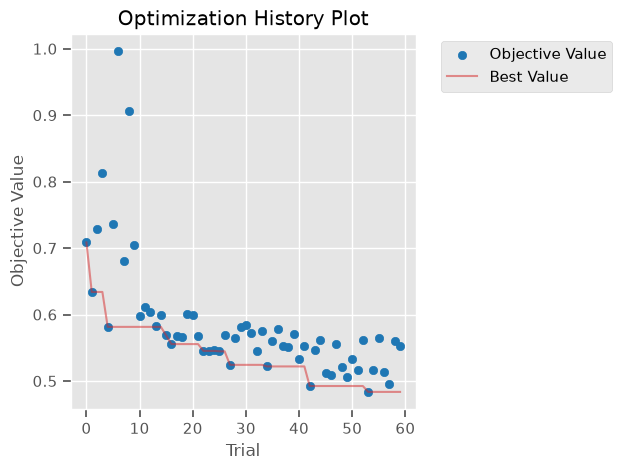

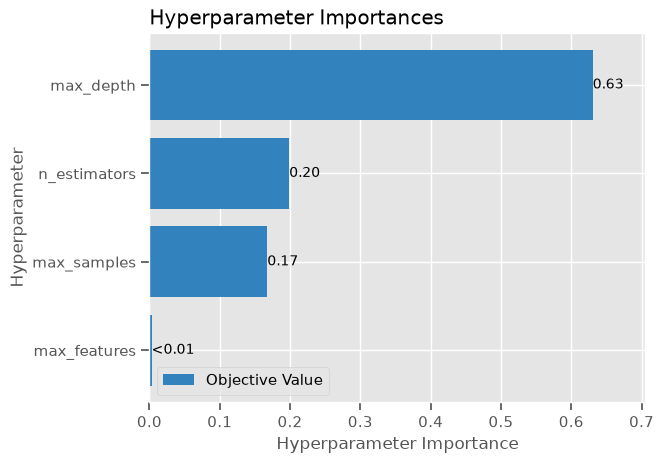

In [51]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_nb.best_params)
print("Лучшее среднее значение missed_defaults_rate на кросс-валидации:", study_nb.best_value)

plot_optimization_history(study_nb)
plot_param_importances(study_nb)
plt.show()

Далее подберем для модели, учитывающей баланс классов.

In [52]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 10, 100),
        "max_depth": trial.suggest_int("max_depth", 5, 25),
        "max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2', None]),
        "max_samples": trial.suggest_float("max_samples", 0.6, 1.0)
    }
    
    model = ImbPipeline([('preprocessing', rf_preprocessor),
                         ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                         ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state, **params))])
    metrics = []
    for i, (train_idx, val_idx) in enumerate(gtscv.split(X_train_val, y_train_val, groups=groups)):
        X_train = X_train_val.iloc[train_idx].copy()
        y_train = y_train_val.iloc[train_idx].copy()
        
        X_val = X_train_val.iloc[val_idx].copy()
        y_val = y_train_val.iloc[val_idx].copy()
        
        model.fit(X_train,y_train)
        y_pred_proba = model.predict_proba(X_val)[:,1]
        metrics.append(missed_defaults_rate(y_val, y_pred_proba))
    
    return pd.Series(metrics).mean()

sampler = optuna.samplers.TPESampler(seed=random_state)
study_b = optuna.create_study(direction="minimize", sampler=sampler)
study_b.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-09-28 16:12:50,590] A new study created in memory with name: no-name-005b66bc-9f80-4258-ac72-83558b9547a7


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-09-28 16:12:51,717] Trial 0 finished with value: 0.16188081925364525 and parameters: {'n_estimators': 44, 'max_depth': 24, 'max_features': 'sqrt', 'max_samples': 0.662397808134481}. Best is trial 0 with value: 0.16188081925364525.
[I 2026-09-28 16:12:52,432] Trial 1 finished with value: 0.18935069444353336 and parameters: {'n_estimators': 15, 'max_depth': 23, 'max_features': 'log2', 'max_samples': 0.9879639408647978}. Best is trial 0 with value: 0.16188081925364525.
[I 2026-09-28 16:12:58,026] Trial 2 finished with value: 0.17197463504422342 and parameters: {'n_estimators': 85, 'max_depth': 9, 'max_features': None, 'max_samples': 0.8099025726528951}. Best is trial 0 with value: 0.16188081925364525.
[I 2026-09-28 16:12:59,044] Trial 3 finished with value: 0.11660450800943822 and parameters: {'n_estimators': 49, 'max_depth': 11, 'max_features': 'sqrt', 'max_samples': 0.7465447373174767}. Best is trial 3 with value: 0.11660450800943822.
[I 2026-09-28 16:13:03,756] Trial 4 finished

[I 2026-09-28 16:13:35,430] Trial 33 finished with value: 0.059961386991341015 and parameters: {'n_estimators': 82, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.8698653524938575}. Best is trial 17 with value: 0.05807208192830219.
[I 2026-09-28 16:13:36,600] Trial 34 finished with value: 0.059911696634600685 and parameters: {'n_estimators': 91, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.9078129656127497}. Best is trial 17 with value: 0.05807208192830219.
[I 2026-09-28 16:13:37,972] Trial 35 finished with value: 0.06646519996565932 and parameters: {'n_estimators': 100, 'max_depth': 6, 'max_features': 'sqrt', 'max_samples': 0.8345520850819087}. Best is trial 17 with value: 0.05807208192830219.
[I 2026-09-28 16:13:38,885] Trial 36 finished with value: 0.060917472437872634 and parameters: {'n_estimators': 68, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7568689672484221}. Best is trial 17 with value: 0.05807208192830219.
[I 2026-09-28 16:13:39,788] Tria

[I 2026-09-28 16:14:13,327] Trial 66 finished with value: 0.05879828242881117 and parameters: {'n_estimators': 98, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.6585774021335056}. Best is trial 17 with value: 0.05807208192830219.
[I 2026-09-28 16:14:14,338] Trial 67 finished with value: 0.09877025338768886 and parameters: {'n_estimators': 59, 'max_depth': 9, 'max_features': 'log2', 'max_samples': 0.6117727428454162}. Best is trial 17 with value: 0.05807208192830219.
[I 2026-09-28 16:14:15,571] Trial 68 finished with value: 0.059605362162833554 and parameters: {'n_estimators': 97, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.7356221198419708}. Best is trial 17 with value: 0.05807208192830219.
[I 2026-09-28 16:14:16,737] Trial 69 finished with value: 0.05702975304001897 and parameters: {'n_estimators': 88, 'max_depth': 5, 'max_features': 'log2', 'max_samples': 0.6613782373790594}. Best is trial 69 with value: 0.05702975304001897.
[I 2026-09-28 16:14:17,896] Trial 7

[I 2026-09-28 16:14:52,238] Trial 99 finished with value: 0.059008788236526444 and parameters: {'n_estimators': 91, 'max_depth': 5, 'max_features': 'sqrt', 'max_samples': 0.664898596168507}. Best is trial 69 with value: 0.05702975304001897.


Лучшие гиперпараметры: {'n_estimators': 88, 'max_depth': 5, 'max_features': 'log2', 'max_samples': 0.6613782373790594}
Лучшее среднее значение missed_defaults_rate на кросс-валидации: 0.05702975304001897


C:\Users\EA\AppData\Local\Temp\ipykernel_24332\733731771.py:5: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study_b)
C:\Users\EA\AppData\Local\Temp\ipykernel_24332\733731771.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study_b)


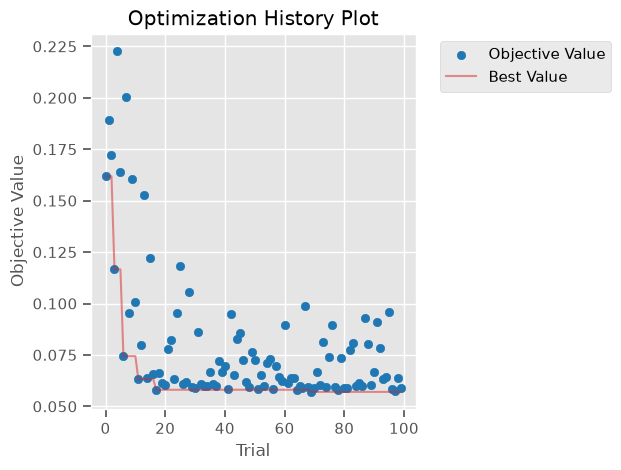

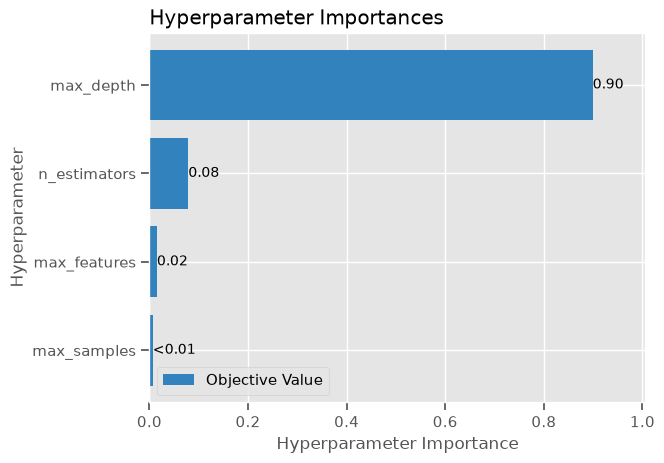

In [53]:
# Лучшие гиперпараметры и качество
print("Лучшие гиперпараметры:", study_b.best_params)
print("Лучшее среднее значение missed_defaults_rate на кросс-валидации:", study_b.best_value)

plot_optimization_history(study_b)
plot_param_importances(study_b)
plt.show()

<a id='p7c'></a>

---

### Сравнение и выводы по моделям

[К Содержимому проекта](#contents)

Рассчитаем метрики на калибровочной выборке для всех четырех моделей. Дополнительно выведем метрики на тренировочной выборке для оценки переобучения.

In [54]:
def calculate_ece(y_true, y_pred_prob, n_bins=10):
    # Создаем границы бинов от 0 до 1, например, [0.0, 0.1, ..., 1.0].
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0 
    n = len(y_true)
    # Итерируемся по каждому бину.
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Создаем логическую маску для отбора примеров, которые попадают в текущий бин.
        # Последний бин (i == n_bins - 1) включает правую границу, чтобы захватить
        # вероятность 1.0, остальные - нет.
        if i == n_bins - 1:
            mask = (y_pred_prob >= bin_lower) & (y_pred_prob <= bin_upper)
        else:
            mask = (y_pred_prob >= bin_lower) & (y_pred_prob < bin_upper)
        # Проверяем, есть ли в текущем бине хотя бы один пример.
        if np.sum(mask) > 0:
            bin_size = np.sum(mask)
            # Вычисляем среднюю предсказанную уверенность (confidence) для бина.
            bin_conf = np.mean(y_pred_prob[mask])
            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask])
            # Вычисляем вклад текущего бина в общую ошибку.
            # Это абсолютная разница, умноженная на количество примеров в бине.
            contribution = np.abs(bin_conf - bin_acc) * bin_size
            ece += contribution
    
    return ece / n

def calculate_mce(y_true, y_prob, n_bins=10):
    # Создаем границы бинов от 0 до 1, например, [0.0, 0.1, ..., 1.0].
    bins = np.linspace(0, 1, n_bins + 1)
    # Инициализируем максимальную ошибку
    max_error = -1
    for i, (bin_lower, bin_upper) in enumerate(zip(bins[:-1], bins[1:])):
        # Последний бин включает верхнюю границу (1.0).
        if i == n_bins - 1:
            mask = (y_prob >= bin_lower) & (y_prob <= bin_upper)
        else:
            mask = (y_prob >= bin_lower) & (y_prob < bin_upper)
        # Продолжаем, только если в бине есть хотя бы один объект.
        if np.sum(mask) > 0:
            # Вычисляем среднюю уверенность модели для этого бина.
            bin_conf = np.mean(y_prob[mask])
            # Вычисляем среднюю точность (долю правильных ответов) в этом бине.
            bin_acc = np.mean(y_true[mask])
            # Вычисляем абсолютную разницу между точностью и уверенностью.
            diff = np.abs(bin_conf - bin_acc)
            # Обновляем максимальную ошибку, если текущая разница больше.
            max_error = max(max_error, diff)
            
    return max_error

def CalcMetricsFinal(y_true, y_pred_proba, cutoff = 0.5, fold_name = 'Unknown', model_name = 'Unknown'):
    y_pred = (y_pred_proba >= cutoff).astype(int)
    return {
        'model_name' : model_name,
        'fold_name' : fold_name,
        'approval_rate' : approval_rate(y_true, y_pred_proba, cutoff),
        'default_rate' : default_rate(y_true, y_pred_proba, cutoff),
        'missed_defaults_rate' : missed_defaults_rate(y_true, y_pred_proba, cutoff),
        'brier_score_loss': brier_score_loss(y_true, y_pred),
        'ECE': calculate_ece(y_true, y_pred_proba, n_bins=20),
        'MCE': calculate_mce(y_true, y_pred_proba, n_bins=20),
        'accuracy' : accuracy_score(y_true, y_pred),
        'roc_auc' : roc_auc_score(y_true, y_pred_proba),
        'pr_auc' : average_precision_score(y_true, y_pred_proba),
        'precision': precision_score(y_true, y_pred),
        'recall': recall_score(y_true, y_pred)
    }

In [55]:
#Pipeline для перебора:
pipelines = {
    'LogReg': Pipeline([('preprocessing', line_preprocessor), 
                        ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'LogReg_mixed': ImbPipeline([('preprocessing', line_preprocessor),
                                 ('over', RandomOverSampler(random_state=random_state, sampling_strategy = 0.3)),
                                 ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                 ('model', LogisticRegression(n_jobs=-1, random_state=random_state, max_iter = 5000))]),
    'RanFor_hyper': Pipeline([("preprocessing", rf_preprocessor), 
                              ("model", RandomForestClassifier(n_jobs=-1, random_state=random_state, **study_nb.best_params))]),
    'RanFor': Pipeline([('preprocessing', rf_preprocessor), 
                        ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_under1': ImbPipeline([('preprocessing', rf_preprocessor),
                                  ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                  ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state))]),
    'RanFor_under_hyper': ImbPipeline([('preprocessing', rf_preprocessor),
                                       ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                                       ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state, **study_b.best_params))])
}

res_df = pd.DataFrame()
for name, model in pipelines.items():
    pr_df = pd.DataFrame(TimeSeriesCrossVal(model, gtscv, groups, X_train_val, y_train_val, name))
    res_df = pd.concat([res_df, pr_df], axis=0, ignore_index=True)

In [56]:
display(res_df.sort_values(by = ['fold_name', 'missed_defaults_rate']))

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,accuracy,roc_auc,pr_auc
6,RanFor,train,0.803 ± 0.016,0.0 ± 0.0,0.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
8,RanFor_under1,train,0.626 ± 0.007,0.0 ± 0.0,0.0 ± 0.0,0.823 ± 0.009,0.992 ± 0.002,0.964 ± 0.012
4,RanFor_hyper,train,0.803 ± 0.016,0.002 ± 0.001,0.008 ± 0.004,0.997 ± 0.001,1.0 ± 0.0,0.999 ± 0.0
10,RanFor_under_hyper,train,0.476 ± 0.049,0.034 ± 0.012,0.083 ± 0.031,0.641 ± 0.033,0.828 ± 0.015,0.5 ± 0.015
2,LogReg_mixed,train,0.589 ± 0.012,0.088 ± 0.016,0.263 ± 0.039,0.682 ± 0.004,0.771 ± 0.022,0.423 ± 0.017
0,LogReg,train,0.949 ± 0.01,0.178 ± 0.013,0.859 ± 0.02,0.808 ± 0.014,0.772 ± 0.021,0.43 ± 0.017
11,RanFor_under_hyper,val,0.524 ± 0.122,0.022 ± 0.017,0.057 ± 0.014,0.673 ± 0.081,0.843 ± 0.054,0.457 ± 0.013
9,RanFor_under1,val,0.63 ± 0.112,0.046 ± 0.023,0.158 ± 0.024,0.746 ± 0.077,0.853 ± 0.057,0.469 ± 0.013
3,LogReg_mixed,val,0.581 ± 0.176,0.058 ± 0.017,0.198 ± 0.066,0.688 ± 0.121,0.801 ± 0.074,0.398 ± 0.024
5,RanFor_hyper,val,0.84 ± 0.048,0.1 ± 0.042,0.484 ± 0.03,0.844 ± 0.055,0.845 ± 0.062,0.516 ± 0.026


<span style="font-size: 16px;">**Выводы**</span>

1. В итоговой версии сравнивались шесть моделей:
    - `LogReg` и `LogReg_mixed`: первая модель обычная логистическая регрессия на исходном наборе строк, а вторая модель с выравниванием классов 1 к 1 засчет увелечения минорного класса, а затем уменьшения мажоритарного.
    - `RanFor` и `RanFor_under1`: модель случайного леса без балансировки и с балансировкой классов, но без подбора гиперпараметров
    - `RanFor_hyper` и `RanFor_under_hyper`: модель случайного леса без/c балансировкой и с подбором гиперпараметров. 
2. Наблюдается некоторая поляризация результатов или мы обеспечиваем высокий `approval_rate`, но при этом достаточно часто пропускаем будущие просрочки (`missed_defaults_rate`). Этот результат обеспечивают модели `RanFor` и `LogReg` ( у моделей `approval_rate` около 91% и 88% соответственно, и `missed_defaults_rate` около 71% и 75%). Такого рода модели из-за дисбаланса классов чаще предсказывают `0` (отсутствие просрочки), что обеспечивает столь высокий `approval_rate`, но при этом пропускают много случившихся дефолтов. В банковской сфере обычно страшнее именно дефолты. Однако, когда они его предсказывают, то бывают достаточно часто правы. При этом стоит отметить переобучение модели `RanFor_non_balanced` даже с подборкой гиперпараметров. Она почти идеально запомнила тестовую выборку, но на калибровочной сталкивается с заметным падением качества.
3. Альтернативные результаты формируют модели с балансировкой классов - `RanFor_under1` и `LogReg_mixed`. Они имеют не высокий `approval_rate` (около 63% и 58%), но при этом редко пропускают просрочки у клиентов (`missed_defaults_rate` около 16% и 20%). Такого рода модели чаще предсказывают положительный класс - просрочку, что приводит к сильному снижению `missed_defaults_rate` по сравнению с моделями без балансировки классов. Уменьшение количества экземпляров класса `0` привело к тому, что модели стали чаще предсказывать класс `1`. Кроме того, скорость обучения и расчетов значительно повысилась, по сравнению с моделями, обученными на полной выборке.
4. Подбор гиперпараметров позволил серьезно повысить качество моделей `RanFor_under_hyper` и `RanFor_hyper`. Количество дефолтов упало до 5.7% и 48%. `approval_rate` тоже снизился (52% и 84%). Однако падение `approval_rate` менее заметно по сравнению со снижением ключевых показателей по `missed_defaults_rate` (здесь падение в разы, а не на 10-20%). В настоящий момент ни одна из моделей не может быть рекомендована к внедрению по бизнес показателям. Требуется калибровка и подбор порога, что может быть позовлит получить требуемые метрики.  
5. Выигрышными по бизнес-метрикам в обоих случаях являются модели случайного леса, что говорит о сложном, нелинейном характере зависимости целевой переменной от предлагаемых методов решения. Логистическая регрессия фактически достигла своего потолка и подбор гиперпараметров ей уже не поможет.

<a id='p8'></a>

---

## Калибровка модели и пересчёт результатов

* Проведем калибровку лучшей версии модели. Используем отдельную калибровочную выборку.
* Используем метод, подходящий для случайного леса.
* Построим график калибровки.
* Сделаем вывод, оценим результаты с помощью коэффициента Бриера, ECE, MCE.

[К Содержимому проекта](#contents)

In [57]:
def calibration_curve_plotter(y_true, y_prob_1, y_prob_2 = None, label_list = ['Random Forest'], n_bins=10):
    plt.figure(figsize=(10,10))
    
    prob_true, prob_pred = calibration_curve(y_true, y_prob_1, n_bins=n_bins, strategy='uniform')
    CalibrationDisplay(prob_true, prob_pred, y_true).plot( ax=plt.gca(), label=label_list[0], color='blue')
    
    if y_prob_2 is not None:
        prob_true, prob_pred = calibration_curve(y_true, y_prob_2, n_bins=n_bins, strategy='uniform')
        CalibrationDisplay(prob_true, prob_pred, y_true).plot( ax=plt.gca(), label=label_list[1], color='red')
    
    plt.title("Диаграмма калибровки")
    plt.xlabel("Средняя предсказанная вероятность")
    plt.ylabel("Фактическая доля положительных исходов")
    plt.legend()
    plt.grid(True)
    plt.show()

In [58]:
rf_under1 = ImbPipeline([('preprocessing', rf_preprocessor),
                         ('under', RandomUnderSampler(random_state=random_state, sampling_strategy = 1)),
                         ('model', RandomForestClassifier(n_jobs=-1, random_state=random_state, **study_b.best_params))])
rf_under1.fit(X_train_val, y_train_val)

C:\Users\EA\JupyterCode\ML_Module_3\ml-env\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['marital_status'])])),
                ('under',
                 RandomUnderSampler(random_state=42, sampling_strategy=1)),
                ('model',
                 RandomForestClassifier(max_depth=5, max_features='log2',
                                        max_samples=0.6613782373790594,
                                        n_estimators=88, n_jobs=-1,
                                        random_state=42))])

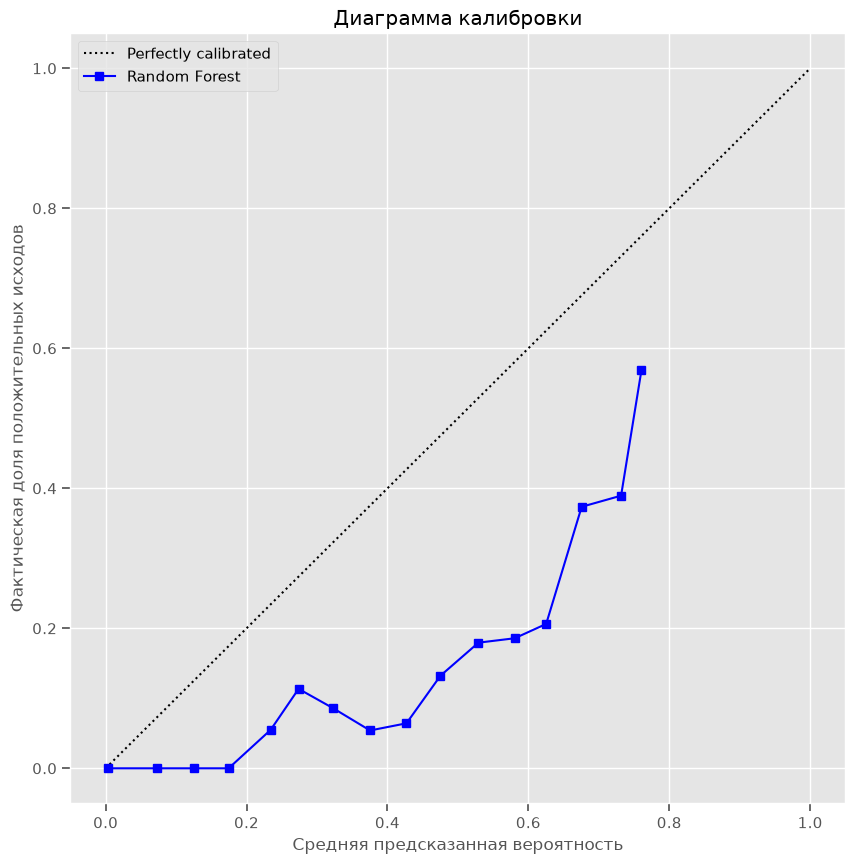

In [59]:
try:
    final_model = FrozenEstimator(rf_under1)
except Exception:
    final_model = rf_under1

y_pred_proba = final_model.predict_proba(X_cal_val)[:, 1]
calibration_curve_plotter(y_cal_val, y_pred_proba, n_bins = 20)

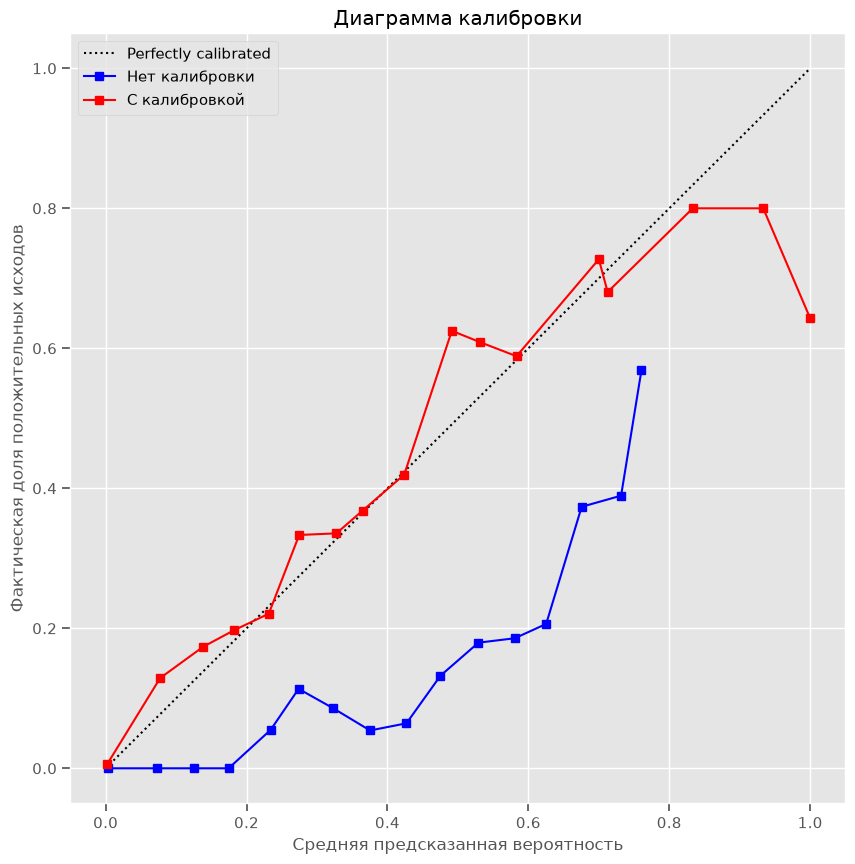

In [60]:
calibrated_final_model = CalibratedClassifierCV(estimator=final_model, method='isotonic' )
calibrated_final_model.fit(X_cal_train, y_cal_train)

y_pred_proba_cal = calibrated_final_model.predict_proba(X_cal_val)[:, 1]
calibration_curve_plotter(y_cal_val, y_pred_proba, y_pred_proba_cal, label_list = ['Нет калибровки', 'С калибровкой'], n_bins=20)

In [61]:
pd.DataFrame([CalcMetricsFinal(y_cal_val, y_pred_proba, cutoff = 0.5, fold_name = 'Cal_Val', model_name = 'RanFor_non_cal')
              ,CalcMetricsFinal(y_cal_val, y_pred_proba_cal, cutoff = 0.5, fold_name = 'Cal_Val', model_name = 'RanFor_cal')
             ])

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,RanFor_non_cal,Cal_Val,0.705974,0.007904,0.056066,0.205662,0.121925,0.419039,0.794338,0.912386,0.455312,0.319509,0.943934
1,RanFor_cal,Cal_Val,0.987349,0.092566,0.918318,0.095916,0.007095,0.357143,0.904084,0.912660,0.435997,0.642586,0.081682


<span style="font-size: 16px;">**Выводы**</span>

1. Модель для калибровки демонстрирует завышенную уверенность в своих результатах на всем диапазоне вероятностей (калибровочная линия находится под диагональю). Калибровка помогла выровнять вероятности модели и сделать их более близким к реальным, хотя на некоторых диапазонах модель вероятности модели начинают сильно калебаться (особенно в зоне высоких вероятностей после 0.7). 
2. Калибровка помогала значительно снизить `brier_score_loss` (более чем в 2 раза), `ECE` (около 15 раз). Разница между `MCE` и `ECE` большая, что сигнализирует о том, что предсказанные вероятности иногда достаточно сильно отличаются от реальных (выбросы как раз располагаются после 0.7).
4. Калибровка меняет значения вероятностей, что привело к тому, что модель теперь реже выдает вероятности больше 0.5 (она перестала быть слишком уверенной). Сейчас она более напонимает модели, работающие с несбалансированной выборкой. Уменьшения порога классификации позволит увеличить количество клиентов, которых моделей считает дефолтными и, возможно, достигнуть требуемых показателей.

<a id='p9'></a>

---

## Поиск порога решения

1. Используем откалиброванную модель и калибровочную выборку, найдем порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate - не менее 65%;
    * default rate - не более 2%;
    * missed defaults rate - не более 4%.
2. Сделаем вывод о достигнутых в этом разделе результатах.

[К Содержимому проекта](#contents)

In [62]:
res_l = []
for cutoff in [0.01, 0.03, 0.04, 0.1, 0.3]:
    dct = {'cutoff' : cutoff}
    dct = dct | CalcMetricsFinal(y_cal_val, y_pred_proba_cal, cutoff = cutoff, fold_name = 'Cal', model_name = 'RanFor_cal')
    res_l.append(dct)

pd.DataFrame(res_l)

,cutoff,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,0.01,RanFor_cal,Cal,0.647338,0.000000,0.000000,0.253139,0.007095,0.357143,0.746861,0.91266,0.435997,0.282207,1.000000
1,0.03,RanFor_cal,Cal,0.651450,0.000369,0.002417,0.249507,0.007095,0.357143,0.750493,0.91266,0.435997,0.284847,0.997583
2,0.04,RanFor_cal,Cal,0.692433,0.005974,0.041566,0.216316,0.007095,0.357143,0.783684,0.91266,0.435997,0.310135,0.958434
3,0.10,RanFor_cal,Cal,0.705998,0.007904,0.056066,0.205638,0.007095,0.357143,0.794362,0.91266,0.435997,0.319535,0.943934
4,0.30,RanFor_cal,Cal,0.831521,0.036792,0.307395,0.130141,0.007095,0.357143,0.869859,0.91266,0.435997,0.409136,0.692605


<span style="font-size: 16px;">**Выводы**</span>

Подбор порога помог достигнуть требуемых по ТЗ показателей. Его оптимальное значение 0.03. При таких значениях:
* `missed_defaults_rate` $\approx$ 0.2% < 4%
* `default_rate` $\approx$ 0.03% < 2%
* `approval_rate` $\approx$ 65.1% > 65%

Такое снижение порога ведет к тому, что модель более охотно говорить, что у человека будет дефолт в будущем. Однако, стоит отметить, что модель не слишком статбильна и сильно зависит от порога. Его значения в 0.05 очень мало по сравнению со значением по умолчанию - 0.5.

<a id='p10'></a>

---

## Анализ матрицы ошибок

1. Оценим стабильность модели на тестовых данных. Для этого построим:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
2. Сделаем вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
3. Сделаем вывод о стабильности модели.

[К Содержимому проекта](#contents)

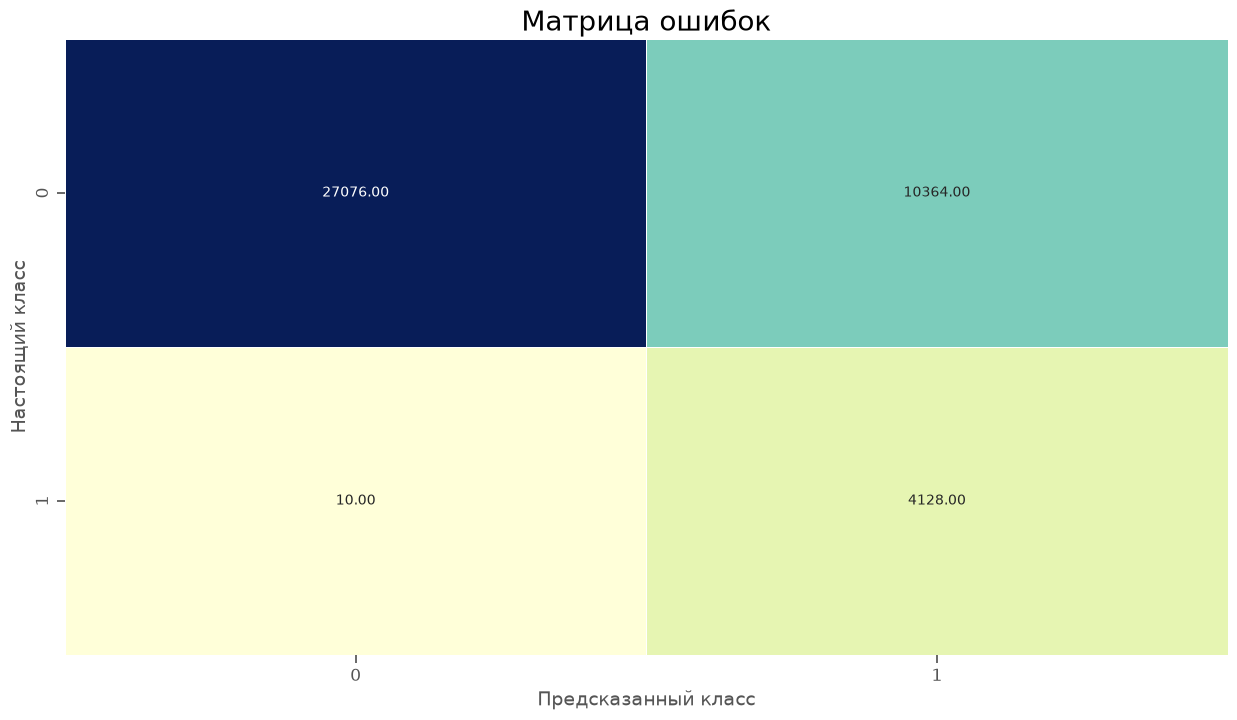

In [63]:
cutoff = 0.03
y_pred_proba_cal = calibrated_final_model.predict_proba(X_cal_val)[:, 1]
y_pred_proba_test = calibrated_final_model.predict_proba(X_test)[:, 1]

y_pred_cal = (y_pred_proba_cal >= cutoff).astype(int)
y_pred_test = (y_pred_proba_test >= cutoff).astype(int)

cm = confusion_matrix(y_cal_val, y_pred_cal)
fig, ax = plt.subplots(figsize=(15,8))
fig = sns.heatmap(cm, 
                annot=True,     # Отображаем численные значения в ячейках карты
                fmt='.2f',      # Форматируем значения корреляции: два знака после точки
                cmap='YlGnBu',  # Устанавливаем цветовую гамму от красного (макс. значение) к синему
                linewidths=0.5, # Форматируем линию между ячейками карты
                cbar=False,     # Отключаем цветовую шкалу
                annot_kws={'size': 10}
                )
plt.title('Матрица ошибок', fontsize=20)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.ylabel('Настоящий класс', fontsize=14)
fig.tick_params(axis='both', labelsize=12)
plt.show()

In [64]:
print(classification_report(y_test, y_pred_test, digits=2))

              precision    recall  f1-score   support

           0       1.00      0.77      0.87     83848
           1       0.35      0.99      0.52     10447

    accuracy                           0.80     94295
   macro avg       0.68      0.88      0.70     94295
weighted avg       0.93      0.80      0.83     94295



In [65]:
pd.DataFrame([CalcMetricsFinal(y_test, y_pred_proba_test, cutoff = cutoff, fold_name = 'Test', model_name = 'RanFor_cal')])

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,RanFor_cal,Test,0.689931,0.00126,0.007849,0.201018,0.022394,0.285714,0.798982,0.909621,0.454406,0.354504,0.992151


<span style="font-size: 16px;">**Выводы**</span>

Построив матрицу ошибок на калибровочной выборке заметна основная проблема модели - она достаточно часто осторожничает и показывает дефолт для человека, у которого дефолта не будет в ближайшие 12 месяцев. При этом она редко пропускает настоящие дефолты (10 штук пропущено из 4138). Это достаточно серьезное преимущество модели. Ее недостаток в том, что она часто ложно срабатывает, причем 2 из 3 срабатываний - ложное. В условии отсутствия средних трат по одному дефолту и по одному ложному срабатыванию сказать что-то определенное сложно. К модели все еще стоит относится с осторожностью, т.к. количество пропущенных дефолтов на тесте резко выросло по сравнению с калибровкой. Бизнес-метрики пляшут.

На тесте модель сохраняет качество и проходит по ТЗ метрикам. `approval_rate` вырос до 69%, а `missed_defaults_rate` и `default_rate` остались в рамках требуемых показателей. 

<a id='p11'></a>

---

## Фиксирование итоговой модели

Опишим лучшую модель и найденный порог классификации. Сохраним найденную модель.

[К Содержимому проекта](#contents)

In [66]:
try:
    joblib.dump(calibrated_final_model, '../models/Final_model.joblib')
except Exception:
    joblib.dump(calibrated_final_model, 'Final_model.joblib')

try:
    loaded_best = joblib.load('./../models/Final_model.joblib')
except Exception:
    loaded_best = joblib.load('Final_model.joblib')

y_pred_proba_train = loaded_best.predict_proba(X_train_val)[:, 1]
y_pred_proba_cal = loaded_best.predict_proba(X_cal)[:, 1]
y_pred_proba_test = loaded_best.predict_proba(X_test)[:, 1]

pd.DataFrame([
    CalcMetricsFinal(y_train_val, y_pred_proba_train, cutoff = cutoff, fold_name = 'Train-Val', model_name = 'loaded_model'),
    CalcMetricsFinal(y_cal, y_pred_proba_cal, cutoff = cutoff, fold_name = 'Cal', model_name = 'loaded_model'),
    CalcMetricsFinal(y_test, y_pred_proba_test, cutoff = cutoff, fold_name = 'Test', model_name = 'loaded_model')
])

,model_name,fold_name,approval_rate,default_rate,missed_defaults_rate,brier_score_loss,ECE,MCE,accuracy,roc_auc,pr_auc,precision,recall
0,loaded_model,Train-Val,0.403105,0.001125,0.002817,0.436786,0.005620,0.264368,0.563214,0.856576,0.452492,0.268996,0.997183
1,loaded_model,Cal,0.638858,0.000276,0.001750,0.260787,0.003741,0.272440,0.739213,0.913762,0.443033,0.278370,0.998250
2,loaded_model,Test,0.689931,0.001260,0.007849,0.201018,0.022394,0.285714,0.798982,0.909620,0.454400,0.354504,0.992151


<span style="font-size: 16px;">**Выводы**</span>

Финальная модель была сохранена вместе с процедурами, готовившими данные для нее. Итоговая модель проходит по бизнес-метрикам, однако, стоит сделать замечание о ее стабильности при переходе от старых данных к новым происходит рост всех бизнес-показателей, что хорошо для `approval_rate`, но плохо для `default_rate` и `missed_defaults_rate` (модель чаще пропускает настоящие просрочки у клиента). В случае `missed_defaults_rate` она уже опасно приблизилась к порогу качества. Модель следует дообучать на новых данных, пересматривать порог качества и гиперпараметры время от времени (она достаточно чувствительна к ним). В целом, не смотря на всю критику, модель очень хорошо определяет настоящие просрочки по платежам в будущем и практически не пропускает дефолтов. Однако, она часто ошибочно предсказывает дефолт для клиента, у которого его не будет. В рамках текущего горизонта прогнозирования - год, это хороший резльтат. Возможно, точность удастся повысить, если уменьшить горизонт с 12 до 9 месяцев например. Хотя это потребует отдельных исследований. Кроме того, возможно, стоит удалить ряд признаков, которые слабо влияют на модель и целевую переменную.

<a id='p12'></a>

---

## Анализ важности признаков

1. Проведем анализ важности признаков найденной модели на полных тренировочных данных.
2. Сделаем вывод о силе влияния признаков на дефолт.

[К Содержимому проекта](#contents)

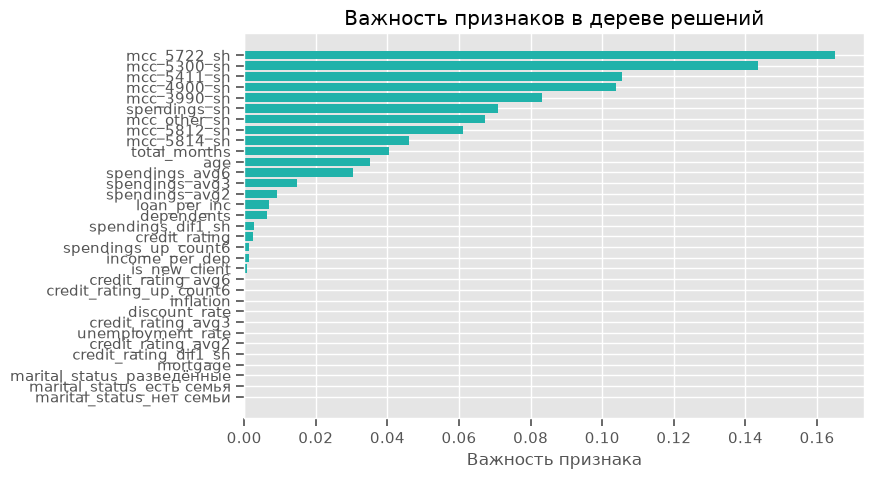

In [67]:
all_feature_name = rf_preprocessor['cat_ohe'].get_feature_names_out(ohe_rf).tolist() + num_rf

# Получение и сортировка по возрастанию важности признаков
importances = pd.Series(final_model['model'].feature_importances_, index=all_feature_name)
importances = importances.sort_values(ascending=True)

# Визуализация
plt.figure(figsize=(8, 5))
plt.barh(importances.index, importances.values, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.show()

<span style="font-size: 16px;">**Выводы**</span>

При оценке важности признаков стоит напомнить, что все расходы измеряются в долях дохода на одного человека в семье на момент получения кредита в банке. В абсолютных значениях хранится только значение самого дохода (`income_per_dep`). Наиболее значимыми признакам для модели являются расходы за предыдущий месяц (суммарно и по категориям), возраст, стаж клиента в банке, а также средние траты за последние месяцы. Неважными для модели является семейный статус человека, наличие или отсутствие ипотеки у него (в целом логично, т.к. по данным ипотека и есть кредит), слабое влияние оказывают макропозатели - процент безработного населения, инфляция в предыдущий меся и даже ставка (возможное объяснение - все эти показатели в основном влияют на ставку с лагом, а ставка влияет на проценты по кредиту в момент выдачи, а значит они более полезны для кредитного скоринга, а в данном случае рассматривается другая задача). Часть показателей, характеризующие кридитный рейтинг не важна для модели (например, `credit_rating_dif1_sh` или `credit_rating_up_count6` - разница между текущим и предыдущим месяцом, или количество месяцов роста рейтинга за последние полгода). 

<a id='p13'></a>

---

## Выводы по проекту

[К Содержимому проекта](#contents)

<span style="font-size: 18px;">**1. Цель и задачи исследования**</span>

Цель проекта - разработать модель поведенческого кредитного скоринга, которая по информации, доступной на момент оценки клиента, прогнозирует возникновение просрочки более 90 дней в течение следующих 12 месяцев. Основные бизнес-ограничения: `approval rate` не менее 65%, `default rate` не более 2% и `missed_defaults_rate` не более 4%.

В рамках проекта проведены исследовательский анализ данных, объединение восьми исходных таблиц, формирование целевой переменной и новых признаков, сравнение логистической регрессии и случайного леса, балансировка классов, подбор гиперпараметров, калибровка вероятностей и поиск бизнес-порога.

<span style="font-size: 18px;">**2. Подготовка данных и выборок**</span>

* Итоговый датасет содержит 334696 наблюдений и 32 признака за период с января 2013 по декабрь 2018 года. Последний год данных был удален, поскольку для него невозможно корректно сформировать полный 12-месячный горизонт прогнозирования.
* Пропуски, дубликаты, выбросы и аномалии, не соответствующие предметной области, не выявлены.
* Целевая переменная сформирована с учетом временной структуры: `1` означает возникновение просрочки более 90 дней в течение следующих 12 месяцев, `0` - ее отсутствие.
* Доля положительного класса составляет около 13,3%, поэтому при построении моделей учитывался выраженный дисбаланс классов.
* Для моделирования были созданы признаки финансовой нагрузки, структуры и динамики расходов, кредитного рейтинга и стажа клиента в банке.
* Все признаки должны отражать информацию, доступную на момент скоринга. Разделение данных и кросс-валидация выполнялись с сохранением временного порядка, чтобы исключить использование информации из будущего.

<span style="font-size: 18px;">**3. Поиск и настройка модели**</span>

На первом этапе были сравнены логистическая регрессия и случайный лес с различными вариантами балансировки классов. Модели без балансировки (`LogReg` и `RanFor`) показывали высокий `approval rate` - около 88-91%, но при этом пропускали большую часть будущих дефолтов: `missed_defaults_rate` составлял около 75% и 71% соответственно.

Балансировка классов позволила значительно снизить долю пропущенных дефолтов. Для `RanFor_under1` и `LogReg_mixed` она снизилась примерно до 16% и 20%, однако одновременно `approval rate` оказался ниже требуемого уровня - около 63% и 58%.

Дополнительный подбор гиперпараметров случайного леса с помощью `Optuna` дал более существенное улучшение. Для `RanFor_under_hyper` `missed_defaults_rate` снизился примерно до 5,7%, а для `RanFor_hyper` - до 48%. При этом `approval rate` составил около 52% и 84% соответственно. Несмотря на заметное улучшение, ни одна из моделей на данном этапе не соответствовала всем бизнес-требованиям одновременно.

По сравнению с логистической регрессией случайный лес показал более высокое качество по бизнес-метрикам. Это указывает на наличие нелинейных зависимостей между характеристиками клиента и вероятностью будущей просрочки.

<span style="font-size: 18px;">**4. Калибровка вероятностей**</span>

Для выбранной версии случайного леса была выполнена калибровка вероятностей на отдельной выборке. До калибровки модель была склонна завышать уверенность в своих прогнозах, особенно при высоких значениях вероятности.

Калибровка существенно улучшила качество вероятностных оценок: `Brier score` снизилась более чем в два раза, а `ECE` - примерно в 15 раз. При этом после калибровки модель стала реже выдавать высокие вероятности дефолта и приблизилась по своему поведению к моделям, обученным на несбалансированной выборке.

Таким образом, калибровка улучшила именно качество вероятностных оценок, но сама по себе не обеспечила требуемых бизнес-показателей. Для получения необходимого соотношения между одобрением и выявлением дефолтов потребовалась дополнительная настройка порога классификации.

<span style="font-size: 18px;">**5. Оптимизация бизнес-порога**</span>

Для откалиброванной модели был подобран порог классификации, при котором выполняются все требования ТЗ. Оптимальным на калибровочной выборке оказалось значение 0,03.

При данном пороге:

* `approval rate` $\approx$ 65.1% при требовании > 65%;
* `default rate` $\approx$ 0,03% при требовании < 2%;
* `missed_defaults_rate` $\approx$ 0,2% при требовании < 4%.

Таким образом, на калибровочной выборке все бизнес-ограничения выполняются с запасом. При этом порог 0,03 существенно ниже стандартного значения 0,5. Это означает, что модель должна получать значительно меньшую предсказанную вероятность, чтобы отнести клиента к группе потенциального дефолта.

Низкое значение порога также показывает чувствительность итогового решения к настройке классификатора. Поэтому найденный порог требует дополнительного контроля при работе модели на новых временных периодах.

<span style="font-size: 18px;">**6. Анализ важности признаков**</span>


Наиболее значимыми для модели оказались признаки, характеризующие расходы клиента в предыдущем месяце, причем как суммарные расходы, так и расходы по отдельным категориям. Также существенный вклад внесли возраст клиента, его стаж в банке и средние расходы за последние несколько месяцев.

Слабое влияние продемонстрировали семейный статус, наличие ипотеки и ряд макроэкономических показателей - уровень безработицы, инфляция и учетная ставка. Часть признаков, связанных с динамикой кредитного рейтинга, также оказалась малозначимой, например `credit_rating_dif1_sh` и `credit_rating_up_count6`.

Полученные результаты показывают, что для данной задачи наиболее информативным источником являются поведенческие характеристики клиента и динамика его расходов, тогда как статические характеристики и отдельные макроэкономические показатели дают меньший вклад.

<span style="font-size: 18px;">**7. Финальный пайплайн**</span>

Финальный пайплайн включает подготовку исходных данных, формирование признаков, обработку категориальных данных, обученный случайный лес, калибровку вероятностей и применение найденного **порога 0,03**.

Модель и процедуры подготовки данных были сохранены, что позволяет воспроизводить процесс получения предсказаний для новых наблюдений.

На тестовой выборке модель сохранила соответствие требованиям ТЗ: `approval rate` составил около 69%, а `default rate` и `missed_defaults_rate` остались в допустимых пределах. При этом результаты на тестовой выборке отличаются от результатов на калибровочной, что указывает на изменение распределения данных во времени.

<span style="font-size: 18px;">**8. Основные выводы и рекомендации для бизнеса**</span>

Главным преимуществом модели является способность выявлять большую часть клиентов, у которых в дальнейшем возникает просрочка более 90 дней. На калибровочной выборке было пропущено 10 дефолтов из 4 138, однако одновременно модель часто давала ложные срабатывания: примерно две трети срабатываний приходились на клиентов, у которых дефолта впоследствии не произошло. Поэтому модель ориентирована скорее на раннее выявление потенциально проблемных клиентов, чем на точное определение каждого будущего дефолта.

Отдельно необходимо отметить стабильность модели. При переходе от калибровочных данных к более новым тестовым данным количество пропущенных дефолтов заметно увеличилось, хотя итоговые бизнес-метрики все еще остались в пределах требований. `missed_defaults_rate` приблизился к установленному порогу, поэтому модель нельзя считать полностью стабильной без дополнительного мониторинга.

Для дальнейшего использования рекомендуется:

* регулярно контролировать `approval rate`, `default rate` и `missed_defaults_rate` на новых данных;
* отслеживать изменение распределения целевой переменной и входных признаков во времени;
* периодически пересматривать порог классификации, гиперпараметры и необходимость переобучения;
* проверять стабильность модели на новых временных периодах;
* дополнительно исследовать влияние малозначимых признаков и возможность их исключения;
* отдельно исследовать более короткий горизонт прогнозирования, например 9 месяцев, поскольку это потенциально может изменить соотношение между точностью и горизонтом предупреждения.

Таким образом, итоговый проект позволил построить воспроизводимый пайплайн поведенческого кредитного скоринга и получить модель, которая на отложенном временном периоде выполняет заданные бизнес-требования. При этом основным направлением дальнейшей работы должна стать проверка временной стабильности модели и регулярная адаптация порога и параметров к изменению поведения клиентов.

Ссылка для скачивания проекта, в том числе модели:

https://github.com/AlexandrEvdokimov/Behavioral_scoring_model_for_Va-Bank.git